# Preparing for the Analysis


## Libraries


In [ ]:
# installations
!pip install -U tabpfn-client huggingface_hub catboost==1.2.10 xgboost==3.2.0 tabpfn==6.0.6

In [ ]:
# libraries

# os and login
import os
from huggingface_hub import login # tabpfn replies with an error needing huggingface
from importlib.metadata import version #libraries version

#tokens
your_hf_token = "###"  # huggingface
your_tabpfn_TOKEN = "###"   # tabpfn


#two option for tabpfn
# clinet or local - client is GPU but limited
# https://ux.priorlabs.ai
USE_TABPFN_CLIENT = False

if USE_TABPFN_CLIENT:
    import tabpfn_client
    from tabpfn_client import TabPFNClassifier, set_access_token
    # Authenticate with token
    set_access_token(your_tabpfn_TOKEN)
    print("Using TabPFN client (cloud inference)")
    print("TabPFN client version:", version("tabpfn-client"))
else:
    os.environ["TABPFN_TOKEN"] = your_tabpfn_TOKEN
    os.environ["TABPFN_NO_BROWSER"] = "1"
    login(token=your_hf_token)
    from tabpfn import TabPFNClassifier
    print("Using local TabPFN (model weights will be downloaded)")
    print("TabPFN package version:", version("tabpfn"))


# google drive
from google.colab import drive

import logging
import sys
import ast
import re
from contextlib import contextmanager
import warnings
import time
from tqdm import tqdm
from joblib import Parallel, delayed
import gc

import numpy as np
import pandas as pd
import torch  # deep learning framework

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid') # for publication
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy.stats import multivariate_normal, multivariate_t
from scipy.linalg import block_diag
from scipy.special import logit

from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import roc_curve, balanced_accuracy_score, roc_auc_score, mean_squared_error
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.exceptions import ConvergenceWarning
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier, callback
from catboost import CatBoostClassifier, Pool

Using local TabPFN (model weights will be downloaded)
TabPFN package version: 6.0.6


## Google Drive and paths

In [ ]:
# mount drive
drive.mount('/content/drive')

main_path="/content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/"
os.chdir(main_path)

# real data paths
real_data_path = main_path+ "real_data/"

# path to save intermediate results
sim_results = main_path + "sim_results/"
real_data_results = main_path + "real_data_results/"

# final results
tables_path = main_path +"tables/"
plots_path = main_path + "plots/"


Mounted at /content/drive


## Loading and preparing the real data

### 1st - Echo Note

In [ ]:
data1_path = real_data_path + "data1_echo_notes.pkl"
df1 = pd.read_pickle(data1_path)

# keep only rows with LV_systolic for target
df_lv = df1.dropna(subset=["LV_systolic"]).copy()
NORMAL_VALUES = [0, -1]
TARGET = "y_LV_normal"
df_lv[TARGET] = df_lv["LV_systolic"].apply(lambda x: 0 if x in NORMAL_VALUES else 1)

# shuffle patient groups
rng = np.random.default_rng(42)
order = {sid: i for i, sid in enumerate(rng.permutation(df_lv["subject_id"].drop_duplicates().to_numpy()))}
df_lv = (df_lv.assign(_ord=df_lv["subject_id"].map(order))
               .sort_values(["_ord", "subject_id"], kind="stable")
               .drop(columns="_ord").reset_index(drop=True))

# groups for GroupKFold
groups = df_lv["subject_id"].reset_index(drop=True)

# columns to exclude
drop_cols = [
    "LV_systolic", "text", "row_id", "subject_id", "hadm_id",
    "category", "chartdate", "date_time", "test",
    "contrast", "technical_quality", "doppler", TARGET
]
df_clean = df_lv.drop(columns=drop_cols, errors="ignore").copy()

# handle categorical
num = df_clean.select_dtypes(include=["number", "bool"])
cat = df_clean.select_dtypes(include=["object", "category"])
high_card = [c for c in cat.columns if cat[c].nunique() > 30]
cat_small = cat.drop(columns=high_card, errors="ignore")

X_cat = pd.get_dummies(cat_small, drop_first=True, dummy_na=True)

# combine
X_df1 = pd.concat([num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
const_cols = [c for c in X_df1.columns if X_df1[c].nunique(dropna=True) <= 1]
X_df1 = X_df1.drop(columns=const_cols, errors="ignore").fillna(0.0).astype("float32")

y_df1 = df_lv[TARGET].astype(int).reset_index(drop=True)

print("X_df1:", X_df1.shape, "y_df1:", y_df1.shape, "groups:", groups.nunique(), "patients")

X_df1: (35431, 25) y_df1: (35431,) groups: 19484 patients


### 2nd - Curated Data for Describing Blood Glucose Management in the Intensive Care Unit

In [ ]:
data2_path = real_data_path + "data2_blood_glucose_management.pkl"
df2 = pd.read_pickle(data2_path)

df = df2.copy()

# parse timestamps
for c in ["TIMER","STARTTIME","ENDTIME","GLCTIMER","GLCTIMER_AL"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# insulin events / glucose readings sort per patient
df_ins = df.loc[df["INPUT"].notna()].dropna(subset=["SUBJECT_ID","STARTTIME"]).sort_values(["SUBJECT_ID","STARTTIME"]).reset_index(drop=True)
df_glc = df.loc[df["GLC"].notna()].dropna(subset=["SUBJECT_ID","GLCTIMER"]).sort_values(["SUBJECT_ID","GLCTIMER"]).reset_index(drop=True)

# pair insulin event with the first glucose reading
def next_glc(ins, glc):
    pos = np.searchsorted(glc["GLCTIMER"].to_numpy(), ins["STARTTIME"].to_numpy(), side="right")
    val = np.full(len(ins), np.nan)
    ok = pos < len(glc)
    val[ok] = glc["GLC"].to_numpy(dtype=float)[pos[ok]]
    return ins.assign(GLC_next=val)

glc_by_sub = dict(tuple(df_glc.groupby("SUBJECT_ID", sort=False)))
pairs = [next_glc(ins, glc_by_sub[sid]) for sid, ins in df_ins.groupby("SUBJECT_ID", sort=False) if sid in glc_by_sub]
df_merged2 = pd.concat(pairs, ignore_index=True).dropna(subset=["GLC_next"]).reset_index(drop=True)

# binary target
TARGET = "y_glucose_normal"
df_merged2[TARGET] = df_merged2["GLC_next"].between(70, 180).astype("int8")

# drop
df_merged2 = df_merged2.loc[~(df_merged2["GLC_AL"].notna() & df_merged2["GLC_AL"].le(0))].reset_index(drop=True)

# shuffle patient groups
rng = np.random.default_rng(42)
order = {sid: i for i, sid in enumerate(rng.permutation(df_merged2["SUBJECT_ID"].drop_duplicates().to_numpy()))}
df_merged2 = (df_merged2.assign(_ord=df_merged2["SUBJECT_ID"].map(order))
                         .sort_values(["_ord","STARTTIME"], kind="stable")
                         .drop(columns="_ord").reset_index(drop=True))

# predictors
predictors = ["LOS_ICU_days","first_ICU_stay","INPUT","INPUT_HRS","INSULINTYPE","EVENT",
               "INFXSTOP","GLCSOURCE","GLC_AL","GLCSOURCE_AL","RULE"]

df_merged2["RULE"] = df_merged2["RULE"].apply(lambda v: f"rule_{int(v)}" if pd.notna(v) else np.nan).astype("object")
for c in ["INSULINTYPE","EVENT","GLCSOURCE","GLCSOURCE_AL","RULE"]:
    df_merged2[c] = df_merged2[c].astype("category")

# build raw X
X_raw = df_merged2[predictors].reset_index(drop=True)

# clean X
num = X_raw.select_dtypes(include=["number", "bool"])
cat = X_raw.select_dtypes(include=["object", "category"])
X_cat = pd.get_dummies(cat, drop_first=True, dummy_na=True)
X_df2 = pd.concat([num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
const_cols = [c for c in X_df2.columns if X_df2[c].nunique(dropna=True) <= 1]
X_df2 = X_df2.drop(columns=const_cols).fillna(0.0).astype("float32")

#  y & groups
y_df2 = df_merged2[TARGET].astype(int).reset_index(drop=True)
groups = df_merged2["SUBJECT_ID"].reset_index(drop=True)

print("X_df2:", X_df2.shape, "y_df2:", y_df2.shape, "groups:", groups.nunique(), "patients")

X_df2: (141430, 16) y_df2: (141430,) groups: 9264 patients


### 3rd - Blood Gas and Oximetry

In [ ]:
data3_path = real_data_path + "data3_blood_gas_oximetry.pkl"
df3 = pd.read_pickle(data3_path)

# target
THRESH_SAO2 = 94.0
assert 'SaO2' in df3.columns, "SaO2 column missing"
df_temp = df3.copy()
df_temp['y'] = (df_temp['SaO2'] < THRESH_SAO2).astype(int)

rng = np.random.default_rng(42)
order = {sid: i for i, sid in enumerate(rng.permutation(df_temp['unique_subject_id'].drop_duplicates().to_numpy()))}
df_temp = (df_temp.assign(_ord=df_temp['unique_subject_id'].map(order))
                 .sort_values(['_ord', 'unique_subject_id'], kind='stable')
                 .drop(columns='_ord')
                 .reset_index(drop=True))

groups = df_temp['unique_subject_id']

# drop
abg_cols = ['SaO2', 'pO2', 'pCO2', 'pH', 'Carboxyhemoglobin', 'Methemoglobin']
outcome_cols = ['in_hospital_mortality', 'los_hospital', 'los_ICU']
time_cols = [c for c in df_temp.columns if 'timestamp' in c.lower() or c.startswith('datetime_')]
future_cols = [c for c in df_temp.columns if c.startswith('sofa_future_')]
id_cols = ['unique_subject_id', 'unique_hospital_admission_id', 'unique_icustay_id',
           'subject_id', 'hospital_admission_id', 'icustay_id', 'hospitalid']

drop_cols = set(abg_cols + outcome_cols + time_cols + future_cols + id_cols + ['y'])  # 'y' is the target

# X
keep_df = df_temp.drop(columns=list(drop_cols), errors='ignore')
num = keep_df.select_dtypes(include=['number'])
cat = keep_df.select_dtypes(include=['object', 'category'])

X_df3 = pd.concat([num, pd.get_dummies(cat, drop_first=True, dummy_na=True)], axis=1).astype('float32')

const_cols = [c for c in X_df3.columns if X_df3[c].nunique(dropna=True) <= 1]
X_df3 = X_df3.drop(columns=const_cols, errors='ignore').fillna(0.0)

# y
y_df3 = df_temp['y'].astype(int)

print("X_df3:", X_df3.shape, "y_df3:", y_df3.shape, "groups:", groups.nunique(), "patients")

X_df3: (49093, 126) y_df3: (49093,) groups: 44902 patients


# Models & Simulation Function

1.   Modeling
2.   Simulation for synthetic data
3.   Resampling for Real data
4.   Saving results



## 1. Fitting a Model for each approach

**Methods Selected vs. Tunning Situation**

| Method | Tuning | Settings (On/Off) |
|--------|--------|-------------------|
| Linear Sparse LR | GridCV on C | Imbalance: Off; Device: CPU (n_jobs=1); Early Stop: NA ; Aug: Off |
| Augmented Sparse LR | GridCV on C post-aug | Imbalance: Off; Device: CPU (n_jobs=1); Early Stop: NA; Aug: On |
| Random Forest | GridCV on n_est/depth | Imbalance: Off; Device: CPU (n_jobs=1); Early Stop: NA; Aug: Off |
| XGBoost | GridCV on n_est/depth | Imbalance: Off; Device: CPU (hist, n_jobs=1); Early Stop: Off; Aug: Off |
| CatBoost | GridCV on iter/depth |  Imbalance: Off; Device: CPU (default); Early Stop: Off; Aug: Off |
| TabPFN (No Tune) | None |  Imbalance: Off; Device: CPU; Early Stop: Off; Aug: Off; Suppress Output: On |





In [ ]:
# Linear Sparse Logistic Regression
def run_linear_sparse_logistic_regression(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val):
    # model and tuning grid
    lr = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=2000,
        n_jobs=1,
    )
    param_grid = {'C': np.logspace(-4, 4, 10)}
    grid_search = GridSearchCV(
        lr,
        param_grid,
        cv=[(np.arange(len(X_train_sub)), np.arange(len(X_train_sub), len(X_train_sub) + len(X_val)))],  # indices for train/val
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((X_train_sub, X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_
    # page 276 ITSL book descibes GridSearchCV()

    # best model on full training data
    best_model.fit(X_train, y_train)

    # predict + compute metrics
    pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )



################################################################################



# Sparse Logistic Regression on Augmented Feature Space
def run_sparse_logistic_regression(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val):

    # augment features Function
    def _augment_features(X):
        n, d = X.shape
        idx = np.triu_indices(d, k=0)  # indices for upper triangle + diagonal
        xx = X[:, idx[0]] * X[:, idx[1]]  # element-wise multiplication
        return np.hstack((X, xx))

    # augmentation first
    Aug_X_train = _augment_features(X_train)
    Aug_X_test = _augment_features(X_test)
    Aug_X_train_sub = _augment_features(X_train_sub)
    Aug_X_val = _augment_features(X_val)

    # model and tuning grid
    lr = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=2000,
        n_jobs=1
    )
    param_grid = {'C': np.logspace(-4, 4, 10)}
    grid_search = GridSearchCV(
        lr,
        param_grid,
        cv=[(np.arange(len(Aug_X_train_sub)), np.arange(len(Aug_X_train_sub), len(Aug_X_train_sub) + len(Aug_X_val)))],
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((Aug_X_train_sub, Aug_X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_

    # best model
    best_model.fit(Aug_X_train, y_train)

    # predict
    pred = best_model.predict(Aug_X_test)
    proba = best_model.predict_proba(Aug_X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )

################################################################################


# random forests
def run_random_forest(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val, random_state=None):

    # model and tuning grid
    rf = RandomForestClassifier(
        n_estimators=100, # number of decision trees
        max_depth=5, #important for overfiitng
        n_jobs=1,
        random_state=random_state
    ) # consistent with XGBoost and CatBoost also
    # not include too many parameteres cosidering the grid length
    param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, None]}
    grid_search = GridSearchCV(
        rf,
        param_grid,
        cv=[(np.arange(len(X_train_sub)), np.arange(len(X_train_sub), len(X_train_sub) + len(X_val)))],
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((X_train_sub, X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_

    # train best model on full train
    best_model.fit(X_train, y_train)

    # predict and compute metrics
    pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )


################################################################################


# XGBoost
def run_xgboost(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val, random_state=None):

    # Define model and tuning grid
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=1,
        random_state=random_state
    ) # the same as random forests and catboost
    param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 6]}
    grid_search = GridSearchCV(
        xgb,
        param_grid,
        cv=[(np.arange(len(X_train_sub)), np.arange(len(X_train_sub), len(X_train_sub) + len(X_val)))],
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((X_train_sub, X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_

    # best model on full train data
    best_model.fit(X_train, y_train)

    # predict and compute metrics
    pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )


################################################################################


# CatBoost
def run_catboost(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val, random_state=None):
    #  model and tuning grid
    cb = CatBoostClassifier(
        iterations=100,
        depth=6,
        learning_rate=0.1,
        verbose=0,
        random_seed=random_state
    )# the same as possible
    param_grid = {'iterations': [50, 100, 200], 'depth': [3, 5, 6]}
    grid_search = GridSearchCV(
        cb,
        param_grid,
        cv=[(np.arange(len(X_train_sub)), np.arange(len(X_train_sub), len(X_train_sub) + len(X_val)))],
        scoring='roc_auc',
        n_jobs=1
    )
    grid_search.fit(np.vstack((X_train_sub, X_val)), np.hstack((y_train_sub, y_val)))
    best_model = grid_search.best_estimator_

    # train best model
    best_model.fit(X_train, y_train)

    # predict/ compute metrics
    pred = best_model.predict(X_test)
    proba = best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )


################################################################################

# TabPFN
def run_tabpfn(X_train, X_test, y_train, y_test, random_state=None):
    # scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if USE_TABPFN_CLIENT:
        # Client = limited GPU
        with suppress_output():
            tabpfn = TabPFNClassifier(random_state=random_state)
    else:
        # local
        with suppress_output():
            tabpfn = TabPFNClassifier(
                n_estimators=1,
                device='cpu',            # set to cpu
                inference_precision='auto',
                n_jobs=1,
                ignore_pretraining_limits=True,
                random_state=random_state
            )

    with suppress_output(): # too many useless prints interrupts tqdm
        tabpfn.fit(X_train_scaled, y_train)

    pred = tabpfn.predict(X_test_scaled)
    proba = tabpfn.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)

    return (
        balanced_accuracy_score(y_test, pred),
        roc_auc_score(y_test, proba),
        mean_squared_error(y_test, pred),
        fpr,
        tpr,
        proba
    )

## 2. Simulation - Synthetic data

In [ ]:
# Simulation Function
def simulation(n, mu, sigma1, sigma2, df=5, dist="Normal", iter=100, g_seed=2025):
    n1_tr, n2_tr = n['n1_tr'], n['n2_tr']
    n1_te, n2_te = n['n1_te'], n['n2_te']
    mu1, mu2 = mu['mu1'], mu['mu2']

    np.random.seed(g_seed)

    errors = {
        'L-SLR_MSE': [], 'L-SLR_AUC': [], 'L-SLR_Time': [], 'L-SLR_FPR': [], 'L-SLR_TPR': [],
        'L-SLR_Brier': [], 'L-SLR_CalSlope': [], 'L-SLR_CalIntercept': [],
        'L-SLR_Probas': [],
        'SLR_MSE': [], 'SLR_AUC': [], 'SLR_Time': [], 'SLR_FPR': [], 'SLR_TPR': [],
        'SLR_Brier': [], 'SLR_CalSlope': [], 'SLR_CalIntercept': [],
        'SLR_Probas': [],
        'RandomForest_MSE': [], 'RandomForest_AUC': [], 'RandomForest_Time': [], 'RandomForest_FPR': [], 'RandomForest_TPR': [],
        'RandomForest_Brier': [], 'RandomForest_CalSlope': [], 'RandomForest_CalIntercept': [],
        'RandomForest_Probas': [],
        'XGBoost_MSE': [], 'XGBoost_AUC': [], 'XGBoost_Time': [], 'XGBoost_FPR': [], 'XGBoost_TPR': [],
        'XGBoost_Brier': [], 'XGBoost_CalSlope': [], 'XGBoost_CalIntercept': [],
        'XGBoost_Probas': [],
        'CatBoost_MSE': [], 'CatBoost_AUC': [], 'CatBoost_Time': [], 'CatBoost_FPR': [], 'CatBoost_TPR': [],
        'CatBoost_Brier': [], 'CatBoost_CalSlope': [], 'CatBoost_CalIntercept': [],
        'CatBoost_Probas': [],
        'TabPFN_MSE': [], 'TabPFN_AUC': [], 'TabPFN_Time': [], 'TabPFN_FPR': [], 'TabPFN_TPR': [],
        'TabPFN_Brier': [], 'TabPFN_CalSlope': [], 'TabPFN_CalIntercept': [],
        'TabPFN_Probas': [],
        'y_test_all': []
    }

    for i in tqdm(range(iter), desc=f"Sim {dist} Iterations"):
        global current_iteration  #  warning handler
        current_iteration = i
        warnings.showwarning = capture_warnings

        rng = np.random.RandomState(i+ g_seed)

        if dist == "Normal":
            # generate from Normal
            Tr_x1 = rng.multivariate_normal(mean=mu1, cov=sigma1, size=n1_tr)
            Tr_x2 = rng.multivariate_normal(mean=mu2, cov=sigma2, size=n2_tr)
            Te_x1 = rng.multivariate_normal(mean=mu1, cov=sigma1, size=n1_te)
            Te_x2 = rng.multivariate_normal(mean=mu2, cov=sigma2, size=n2_te)
        elif dist == "t":
            # compute scale matrices
            if df <= 2:
                raise ValueError("Degrees of freedom must be > 2 for valid variance")
            scale1 = sigma1 * (df - 2) / df
            scale2 = sigma2 * (df - 2) / df
            # generate from t-dist
            Tr_x1 = multivariate_t.rvs(loc=mu1, shape=scale1, df=df, size=n1_tr, random_state=rng)
            Tr_x2 = multivariate_t.rvs(loc=mu2, shape=scale2, df=df, size=n2_tr, random_state=rng)
            Te_x1 = multivariate_t.rvs(loc=mu1, shape=scale1, df=df, size=n1_te, random_state=rng)
            Te_x2 = multivariate_t.rvs(loc=mu2, shape=scale2, df=df, size=n2_te, random_state=rng)
        else:
            raise ValueError("dist must be 'Normal' or 't'")

        X_train = np.vstack((Tr_x1, Tr_x2))
        y_train = np.array([0] * n1_tr + [1] * n2_tr)
        X_test = np.vstack((Te_x1, Te_x2))
        y_test = np.array([0] * n1_te + [1] * n2_te)

        # y_test for this iteration
        errors['y_test_all'].append(y_test)

        # Split training data (80/20)
        X_train_sub, X_val, y_train_sub, y_val = train_test_split(
            X_train, y_train, test_size=0.2, stratify=y_train, random_state=i+g_seed
        )

        # run models and store

        # L-SLR
        start_time = time.time()
        logreg_result = run_linear_sparse_logistic_regression(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val)
        errors['L-SLR_Time'].append(time.time() - start_time)
        errors['L-SLR_MSE'].append(logreg_result[2])
        errors['L-SLR_AUC'].append(logreg_result[1])
        errors['L-SLR_FPR'].append(logreg_result[3])
        errors['L-SLR_TPR'].append(logreg_result[4])
        proba = logreg_result[5]
        errors['L-SLR_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['L-SLR_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression(solver='liblinear')
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['L-SLR_CalSlope'].append(cal_model.coef_[0][0])
        errors['L-SLR_CalIntercept'].append(cal_model.intercept_[0])

        # SLR
        start_time = time.time()
        auglogreg_result = run_sparse_logistic_regression(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val)
        errors['SLR_Time'].append(time.time() - start_time)
        errors['SLR_MSE'].append(auglogreg_result[2])
        errors['SLR_AUC'].append(auglogreg_result[1])
        errors['SLR_FPR'].append(auglogreg_result[3])
        errors['SLR_TPR'].append(auglogreg_result[4])
        proba = auglogreg_result[5]
        errors['SLR_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['SLR_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression(solver='liblinear')
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['SLR_CalSlope'].append(cal_model.coef_[0][0])
        errors['SLR_CalIntercept'].append(cal_model.intercept_[0])

        # RF
        start_time = time.time()
        rf_result = run_random_forest(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val, random_state=i+g_seed)
        errors['RandomForest_Time'].append(time.time() - start_time)
        errors['RandomForest_MSE'].append(rf_result[2])
        errors['RandomForest_AUC'].append(rf_result[1])
        errors['RandomForest_FPR'].append(rf_result[3])
        errors['RandomForest_TPR'].append(rf_result[4])
        proba = rf_result[5]
        errors['RandomForest_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['RandomForest_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression(solver='liblinear')
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['RandomForest_CalSlope'].append(cal_model.coef_[0][0])
        errors['RandomForest_CalIntercept'].append(cal_model.intercept_[0])

        # XGBoost
        start_time = time.time()
        xgb_result = run_xgboost(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val, random_state=i+g_seed)
        errors['XGBoost_Time'].append(time.time() - start_time)
        errors['XGBoost_MSE'].append(xgb_result[2])
        errors['XGBoost_AUC'].append(xgb_result[1])
        errors['XGBoost_FPR'].append(xgb_result[3])
        errors['XGBoost_TPR'].append(xgb_result[4])
        proba = xgb_result[5]
        errors['XGBoost_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['XGBoost_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression(solver='liblinear')
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['XGBoost_CalSlope'].append(cal_model.coef_[0][0])
        errors['XGBoost_CalIntercept'].append(cal_model.intercept_[0])

        # CatBoost
        start_time = time.time()
        cb_result = run_catboost(X_train, X_test, y_train, y_test, X_train_sub, y_train_sub, X_val, y_val, random_state=i+g_seed)
        errors['CatBoost_Time'].append(time.time() - start_time)
        errors['CatBoost_MSE'].append(cb_result[2])
        errors['CatBoost_AUC'].append(cb_result[1])
        errors['CatBoost_FPR'].append(cb_result[3])
        errors['CatBoost_TPR'].append(cb_result[4])
        proba = cb_result[5]
        errors['CatBoost_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['CatBoost_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression(solver='liblinear')
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['CatBoost_CalSlope'].append(cal_model.coef_[0][0])
        errors['CatBoost_CalIntercept'].append(cal_model.intercept_[0])

        # TabPFN
        start_time = time.time()
        tabpfn_result = run_tabpfn(X_train, X_test, y_train, y_test, random_state=i+g_seed)
        errors['TabPFN_Time'].append(time.time() - start_time)
        errors['TabPFN_MSE'].append(tabpfn_result[2])
        errors['TabPFN_AUC'].append(tabpfn_result[1])
        errors['TabPFN_FPR'].append(tabpfn_result[3])
        errors['TabPFN_TPR'].append(tabpfn_result[4])
        proba = tabpfn_result[5]
        errors['TabPFN_Probas'].append(proba)
        brier = np.mean((proba - y_test) ** 2)
        errors['TabPFN_Brier'].append(brier)
        proba_clipped = np.clip(proba, 0.001, 0.999)
        logit_proba = logit(proba_clipped)
        cal_model = LogisticRegression(solver='liblinear')
        cal_model.fit(logit_proba.reshape(-1, 1), y_test)
        errors['TabPFN_CalSlope'].append(cal_model.coef_[0][0])
        errors['TabPFN_CalIntercept'].append(cal_model.intercept_[0])

    return errors

## 3. Resampling - Real data

In [ ]:
# resampling Functions for realdata
#  part1 - fucntion for all iterations
def evaluate_on_real_data(X, y, n, iter=100, g_seed = 2025):
    np.random.seed(g_seed)

    X_np = np.asarray(X, dtype=np.float32)
    y_np = np.asarray(y, dtype=int)

    idx0 = np.where(y_np == 0)[0]
    idx1 = np.where(y_np == 1)[0]

    n1_tr, n2_tr = n['n1_tr'], n['n2_tr']
    n1_te, n2_te = n['n1_te'], n['n2_te']

    if len(idx0) < n1_tr + n1_te or len(idx1) < n2_tr + n2_te:
        raise ValueError(
            f"Not enough samples per class.\n"
            f"Class 0: have {len(idx0)}, need {n1_tr + n1_te}\n"
            f"Class 1: have {len(idx1)}, need {n2_tr + n2_te}"
        )

    global capture_warnings

    errors = {
        'L-SLR_MSE': [], 'L-SLR_AUC': [], 'L-SLR_Time': [], 'L-SLR_FPR': [], 'L-SLR_TPR': [],
        'L-SLR_Brier': [], 'L-SLR_CalSlope': [], 'L-SLR_CalIntercept': [], 'L-SLR_Probas': [],
        'SLR_MSE': [], 'SLR_AUC': [], 'SLR_Time': [], 'SLR_FPR': [], 'SLR_TPR': [],
        'SLR_Brier': [], 'SLR_CalSlope': [], 'SLR_CalIntercept': [], 'SLR_Probas': [],
        'RandomForest_MSE': [], 'RandomForest_AUC': [], 'RandomForest_Time': [], 'RandomForest_FPR': [], 'RandomForest_TPR': [],
        'RandomForest_Brier': [], 'RandomForest_CalSlope': [], 'RandomForest_CalIntercept': [], 'RandomForest_Probas': [],
        'XGBoost_MSE': [], 'XGBoost_AUC': [], 'XGBoost_Time': [], 'XGBoost_FPR': [], 'XGBoost_TPR': [],
        'XGBoost_Brier': [], 'XGBoost_CalSlope': [], 'XGBoost_CalIntercept': [], 'XGBoost_Probas': [],
        'CatBoost_MSE': [], 'CatBoost_AUC': [], 'CatBoost_Time': [], 'CatBoost_FPR': [], 'CatBoost_TPR': [],
        'CatBoost_Brier': [], 'CatBoost_CalSlope': [], 'CatBoost_CalIntercept': [], 'CatBoost_Probas': [],
        'TabPFN_MSE': [], 'TabPFN_AUC': [], 'TabPFN_Time': [], 'TabPFN_FPR': [], 'TabPFN_TPR': [],
        'TabPFN_Brier': [], 'TabPFN_CalSlope': [], 'TabPFN_CalIntercept': [], 'TabPFN_Probas': [],
        'y_test_all': []
    }

    # parallel - cahnge n_job for ibe
    results = Parallel(n_jobs=10, prefer="threads", verbose=0)(
        delayed(_single_real_iteration)(
            i, X_np, y_np, idx0, idx1,
            n1_tr, n2_tr, n1_te, n2_te,
            capture_warnings, g_seed
        )
        for i in tqdm(range(iter), desc="Real‑data resampling",
                                     leave=True,
                                     position=0, ncols=80, mininterval=0.5)
    )
    print("parallel done - aggregating results...")
    t0 = time.time()

    for res in results:
        errors['y_test_all'].append(res['y_test'])
        for key, prefix in [
            ('L-SLR', 'L-SLR_'),
            ('SLR', 'SLR_'),
            ('RandomForest', 'RandomForest_'),
            ('XGBoost', 'XGBoost_'),
            ('CatBoost', 'CatBoost_'),
            ('TabPFN', 'TabPFN_')
        ]:
            (t, mse, auc, fpr, tpr, proba, brier, slope, intercept) = res[key]
            errors[prefix + 'Time'].append(t)
            errors[prefix + 'MSE'].append(mse)
            errors[prefix + 'AUC'].append(auc)
            errors[prefix + 'FPR'].append(fpr)
            errors[prefix + 'TPR'].append(tpr)
            errors[prefix + 'Brier'].append(brier)
            errors[prefix + 'CalSlope'].append(slope)
            errors[prefix + 'CalIntercept'].append(intercept)
            errors[prefix + 'Probas'].append(proba)
    print(f"aggregation time: {time.time() - t0:.2f} seconds")
    return errors




# part2 - fucntion for single iteration calcualtion
def _single_real_iteration(i, X_np, y_np, idx0, idx1,
                           n1_tr, n2_tr, n1_te, n2_te,
                           capture_warnings, g_seed):
    global current_iteration
    current_iteration = i
    warnings.showwarning = capture_warnings

    np.random.seed(g_seed)

    rng = np.random.default_rng(seed=i+g_seed)

    train0 = rng.choice(idx0, size=n1_tr, replace=False)
    train1 = rng.choice(idx1, size=n2_tr, replace=False)
    remaining0 = np.setdiff1d(idx0, train0, assume_unique=True)
    remaining1 = np.setdiff1d(idx1, train1, assume_unique=True)
    test0 = rng.choice(remaining0, size=n1_te, replace=False)
    test1 = rng.choice(remaining1, size=n2_te, replace=False)

    train_idx = np.concatenate([train0, train1])
    test_idx = np.concatenate([test0, test1])
    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    X_train = X_np[train_idx]
    y_train = y_np[train_idx]
    X_test = X_np[test_idx]
    y_test = y_np[test_idx]

    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=i+g_seed
    )

    # L-SLR
    start = time.time()
    res = run_linear_sparse_logistic_regression(X_train, X_test, y_train, y_test,
                                                 X_train_sub, y_train_sub, X_val, y_val)
    lslr_time = time.time() - start
    lslr_mse, lslr_auc, lslr_fpr, lslr_tpr, lslr_proba = res[2], res[1], res[3], res[4], res[5]
    lslr_brier = np.mean((lslr_proba - y_test) ** 2)
    lslr_proba_clipped = np.clip(lslr_proba, 0.001, 0.999)
    lslr_logit = logit(lslr_proba_clipped)
    lslr_cal = LogisticRegression(solver='liblinear')
    lslr_cal.fit(lslr_logit.reshape(-1, 1), y_test)
    lslr_slope = lslr_cal.coef_[0][0]
    lslr_intercept = lslr_cal.intercept_[0]

    # SLR
    start = time.time()
    res = run_sparse_logistic_regression(X_train, X_test, y_train, y_test,
                                         X_train_sub, y_train_sub, X_val, y_val)
    slr_time = time.time() - start
    slr_mse, slr_auc, slr_fpr, slr_tpr, slr_proba = res[2], res[1], res[3], res[4], res[5]
    slr_brier = np.mean((slr_proba - y_test) ** 2)
    slr_proba_clipped = np.clip(slr_proba, 0.001, 0.999)
    slr_logit = logit(slr_proba_clipped)
    slr_cal = LogisticRegression(solver='liblinear')
    slr_cal.fit(slr_logit.reshape(-1, 1), y_test)
    slr_slope = slr_cal.coef_[0][0]
    slr_intercept = slr_cal.intercept_[0]

    # random forest
    start = time.time()
    res = run_random_forest(X_train, X_test, y_train, y_test,
                            X_train_sub, y_train_sub, X_val, y_val, random_state=i+g_seed)
    rf_time = time.time() - start
    rf_mse, rf_auc, rf_fpr, rf_tpr, rf_proba = res[2], res[1], res[3], res[4], res[5]
    rf_brier = np.mean((rf_proba - y_test) ** 2)
    rf_proba_clipped = np.clip(rf_proba, 0.001, 0.999)
    rf_logit = logit(rf_proba_clipped)
    rf_cal = LogisticRegression(solver='liblinear')
    rf_cal.fit(rf_logit.reshape(-1, 1), y_test)
    rf_slope = rf_cal.coef_[0][0]
    rf_intercept = rf_cal.intercept_[0]

    # XGBoost
    start = time.time()
    res = run_xgboost(X_train, X_test, y_train, y_test,
                      X_train_sub, y_train_sub, X_val, y_val, random_state=i+g_seed)
    xgb_time = time.time() - start
    xgb_mse, xgb_auc, xgb_fpr, xgb_tpr, xgb_proba = res[2], res[1], res[3], res[4], res[5]
    xgb_brier = np.mean((xgb_proba - y_test) ** 2)
    xgb_proba_clipped = np.clip(xgb_proba, 0.001, 0.999)
    xgb_logit = logit(xgb_proba_clipped)
    xgb_cal = LogisticRegression(solver='liblinear')
    xgb_cal.fit(xgb_logit.reshape(-1, 1), y_test)
    xgb_slope = xgb_cal.coef_[0][0]
    xgb_intercept = xgb_cal.intercept_[0]

    #  CatBoost
    start = time.time()
    res = run_catboost(X_train, X_test, y_train, y_test,
                       X_train_sub, y_train_sub, X_val, y_val, random_state=i+g_seed)
    cb_time = time.time() - start
    cb_mse, cb_auc, cb_fpr, cb_tpr, cb_proba = res[2], res[1], res[3], res[4], res[5]
    cb_brier = np.mean((cb_proba - y_test) ** 2)
    cb_proba_clipped = np.clip(cb_proba, 0.001, 0.999)
    cb_logit = logit(cb_proba_clipped)
    cb_cal = LogisticRegression(solver='liblinear')
    cb_cal.fit(cb_logit.reshape(-1, 1), y_test)
    cb_slope = cb_cal.coef_[0][0]
    cb_intercept = cb_cal.intercept_[0]

    # tabpfn
    start = time.time()
    res = run_tabpfn(X_train, X_test, y_train, y_test, random_state=i+g_seed)
    tpf_time = time.time() - start
    tpf_mse, tpf_auc, tpf_fpr, tpf_tpr, tpf_proba = res[2], res[1], res[3], res[4], res[5]
    tpf_brier = np.mean((tpf_proba - y_test) ** 2)
    tpf_proba_clipped = np.clip(tpf_proba, 0.001, 0.999)
    tpf_logit = logit(tpf_proba_clipped)
    tpf_cal = LogisticRegression(solver='liblinear')
    tpf_cal.fit(tpf_logit.reshape(-1, 1), y_test)
    tpf_slope = tpf_cal.coef_[0][0]
    tpf_intercept = tpf_cal.intercept_[0]

    return {
        'y_test': y_test,
        'L-SLR': (lslr_time, lslr_mse, lslr_auc, lslr_fpr, lslr_tpr, lslr_proba, lslr_brier, lslr_slope, lslr_intercept),
        'SLR': (slr_time, slr_mse, slr_auc, slr_fpr, slr_tpr, slr_proba, slr_brier, slr_slope, slr_intercept),
        'RandomForest': (rf_time, rf_mse, rf_auc, rf_fpr, rf_tpr, rf_proba, rf_brier, rf_slope, rf_intercept),
        'XGBoost': (xgb_time, xgb_mse, xgb_auc, xgb_fpr, xgb_tpr, xgb_proba, xgb_brier, xgb_slope, xgb_intercept),
        'CatBoost': (cb_time, cb_mse, cb_auc, cb_fpr, cb_tpr, cb_proba, cb_brier, cb_slope, cb_intercept),
        'TabPFN': (tpf_time, tpf_mse, tpf_auc, tpf_fpr, tpf_tpr, tpf_proba, tpf_brier, tpf_slope, tpf_intercept),
    }




## 4. Save results as .csv files

In [ ]:

# metadata for synthetic
def make_metadata(n, mu, dist, iter):
    return (f"n_tr={n['n1_tr']}/{n['n2_tr']} |"
           f"n_te={n['n1_te']}/{n['n2_te']} |"
           f"dim={len(mu['mu1'])} |"
           f"distribution={dist} |"
           f"iterations={iter}")
# metadata for real data
def make_real_metadata(dataset_name, n, iter):
    return (f"Dataset: {dataset_name} | "
            f"n_tr={n['n1_tr']}/{n['n2_tr']} | "
            f"n_te={n['n1_te']}/{n['n2_te']} | "
            f"iterations={iter}")


#################################################################################

# Summary Table
def create_summary(errors, setting_name="", metadata=None):

    methods = ['L-SLR', 'SLR', 'RandomForest', 'XGBoost', 'CatBoost', 'TabPFN']

    summary_dict = {}

    for method in methods:
        method_data = {}

        # AUC
        auc_key = f"{method}_AUC"
        if auc_key in errors and errors[auc_key]:
            method_data['AUC_Mean'] = np.mean(errors[auc_key])
            method_data['AUC_Std'] = np.std(errors[auc_key])
        else:
            method_data['AUC_Mean'] = np.nan
            method_data['AUC_Std'] = np.nan

        # MSE
        mse_key = f"{method}_MSE"
        if mse_key in errors and errors[mse_key]:
            method_data['MSE_Mean'] = np.mean(errors[mse_key])
            method_data['MSE_Std'] = np.std(errors[mse_key])
        else:
            method_data['MSE_Mean'] = np.nan
            method_data['MSE_Std'] = np.nan

        # Time
        time_key = f"{method}_Time"
        if time_key in errors and errors[time_key]:
            method_data['Time_Mean'] = np.mean(errors[time_key])
            method_data['Time_Std'] = np.std(errors[time_key])
        else:
            method_data['Time_Mean'] = np.nan
            method_data['Time_Std'] = np.nan

        summary_dict[method] = method_data
    summary_df = pd.DataFrame(summary_dict).T
    summary_df.attrs['metadata'] = metadata
    summary_df = summary_df.sort_values('AUC_Mean', ascending=False) # sort by auc

    return summary_df


#################################################################################

# function to save simulation
def save_simulation_outputs(errors, captured_warnings, setting_name, n, mu, dist, iter_,
                            errors_filename=None, summary_filename=None, warnings_filename=None):

    # default filenames
    if errors_filename is None:
        errors_filename = f"{setting_name.lower().replace(' ', '_')}_errors.csv"
    if summary_filename is None:
        summary_filename = f"{setting_name.lower().replace(' ', '_')}_summary.csv"
    if warnings_filename is None:
        warnings_filename = f"{setting_name.lower().replace(' ', '_')}_warnings.csv"


    # errors
    errors_copy = errors.copy()
    errors_df = pd.DataFrame(errors_copy)
    errors_df.to_csv(sim_results + errors_filename, index=True)
    print(f"✓ Errors saved to {errors_filename}")

    # free memory
    del errors_copy
    del errors_df
    gc.collect()

    # warnings if any
    if captured_warnings:
        warnings_df = pd.DataFrame(captured_warnings)
        warnings_df.to_csv(sim_results + warnings_filename, index=True)
        print(f"✓ Warnings saved to {warnings_filename} (total: {len(captured_warnings)})")
        del warnings_df
    else:
        print(f"✓ No warnings were captured")

    # summary
    summary_df = create_summary(errors, setting_name,
                                metadata=make_metadata(n, mu, dist, iter_))
    summary_df.to_csv(sim_results + summary_filename, index=True)
    print(f"✓ Summary saved to {summary_filename}")

    # memory
    del summary_df
    del errors
    gc.collect()

#################################################################################


# save real data outputs - the same as above
def save_real_data_outputs(errors, captured_warnings, dataset_name, n, iter_,
                           errors_filename=None, summary_filename=None, warnings_filename=None):

    if errors_filename is None:
        errors_filename = f"{dataset_name.lower().replace(' ', '_')}_errors.csv"
    if summary_filename is None:
        summary_filename = f"{dataset_name.lower().replace(' ', '_')}_summary.csv"
    if warnings_filename is None:
        warnings_filename = f"{dataset_name.lower().replace(' ', '_')}_warnings.csv"

    # errors
    errors_copy = errors.copy()
    errors_df = pd.DataFrame(errors_copy)
    errors_df.to_csv(real_data_results + errors_filename, index=True)
    print(f"✓ Errors saved to {errors_filename}")

    del errors_copy, errors_df
    gc.collect()

    # warnings if any
    if captured_warnings:
        warnings_df = pd.DataFrame(captured_warnings)
        warnings_df.to_csv(real_data_results + warnings_filename, index=True)
        print(f"✓ Warnings saved to {warnings_filename} (total: {len(captured_warnings)})")
        del warnings_df
    else:
        print("✓ No warnings were captured")

    # summary
    metadata = make_real_metadata(dataset_name, n, iter_)
    summary_df = create_summary(errors, setting_name=dataset_name, metadata=metadata)
    summary_df.to_csv(real_data_results + summary_filename, index=True)
    print(f"✓ Summary saved to {summary_filename}")

    del summary_df, errors
    gc.collect()

## Suppress & Save warnings

In [ ]:
# there are useless warnings & messages interrupting tqdm - >:(

@contextmanager
def suppress_output():
    # save
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    with open(os.devnull, 'w') as devnull:
        sys.stdout = devnull
        sys.stderr = devnull

        # disable tqdm
        old_tqdm_disable = os.environ.get('TQDM_DISABLE', None)
        os.environ['TQDM_DISABLE'] = '1'

        # tabPFN verbosity
        old_tabpfn_verbose = os.environ.get('TABPFN_VERBOSE', None)
        os.environ['TABPFN_VERBOSE'] = '0'

        try:
            yield
        finally:
            # Restore
            sys.stdout = old_stdout
            sys.stderr = old_stderr
            if old_tqdm_disable is None:
                os.environ.pop('TQDM_DISABLE', None)
            else:
                os.environ['TQDM_DISABLE'] = old_tqdm_disable

            if old_tabpfn_verbose is None:
                os.environ.pop('TABPFN_VERBOSE', None)
            else:
                os.environ['TABPFN_VERBOSE'] = old_tabpfn_verbose

# List for warnings
captured_warnings = []

# needed for warning handler
current_iteration = 0

def capture_warnings(message, category, filename, lineno, file=None, line=None):
    captured_warnings.append({
        'iteration': current_iteration,
        'message': str(message),
        'category': category.__name__,
        'filename': filename,
        'lineno': lineno
    })

# convergenceWarning display
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# tabpfn logging output
logging.getLogger('tabpfn').setLevel(logging.ERROR)

# Running Simulations [! Don't RUN for RESULTS - Results saved in sim_results]



## Setting 1

**Setting 1: Small Sample, Low-Dimensional Gaussian**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathcal{N}(\mu, \Sigma)$                                                                                       |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                  |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20} = \begin{bmatrix} 0 \\ \vdots \\ 0 \end{bmatrix}$                                       |
| **Class 1 Mean**             | $\mu_2 = \begin{bmatrix} 0.7 \\ \vdots \\ 0.7 \\ 0 \\ \vdots \\ 0 \end{bmatrix}_{20\times1}$ (first 10 = 0.7)   |
| **Class 0 Covariance**       | $\Sigma_1 = \mathbf{I}_{20}$  (identity matrix)                                                                 |
| **Class 1 Covariance**       | $\Sigma_2 = \text{diag}(\underbrace{1.3, \ldots, 1.3}_{10}, \underbrace{1, \ldots, 1}_{10})$                     |
| **Signal Features**          | First 10 dimensions carry separation signal                                                                      |
| **Noise Features**           | Last 10 dimensions are pure noise (mean 0, variance 1)                                                           |
| **Separation Strength**      | $\Delta\mu = 0.7$ on 10/20 features → moderate overlap                                                           |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         |
| **Validation**               | 80/20 stratified split inside training                                                                           |


In [ ]:
# setting 1
n1 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu1 = {'mu1': np.zeros(20), 'mu2': np.array([0.7]*10 + [0]*(10))}
sigma1_1 = np.eye(20)
sigma1_2 = np.diag([1.3]*10 + [1]*(10))


# Run simu
errors1 = simulation(n1, mu1, sigma1_1, sigma1_2, dist="Normal", iter=100, g_seed=2025)

# Save
save_simulation_outputs(errors1, captured_warnings,
                        'Setting 1: Small Sample, Low-Dimensional Gaussian',
                        n1, mu1, 'Normal', 100,
                        'errors1.csv', 'summary1.csv', 'setting1_captured_warnings.csv')

Sim Normal Iterations: 100%|██████████| 100/100 [40:18<00:00, 24.18s/it]


✓ Errors saved to errors1.csv
✓ Warnings saved to setting1_captured_warnings.csv (total: 100)
✓ Summary saved to summary1.csv


In [ ]:
# setting 1 sensitivity analysis
n1_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

captured_warnings = []

# Run simulation
errors1_sensitivity = simulation(n1_sensitivity, mu1, sigma1_1, sigma1_2,
                                 dist="Normal", iter=100, g_seed=2026)

# save
save_simulation_outputs(errors1_sensitivity, captured_warnings,
                        'Setting 1 Sensitivity: Larger Training Sample (n_tr=500)',
                        n1_sensitivity, mu1, 'Normal', 100,
                        'errors1_sensitivity.csv', 'summary1_sensitivity.csv',
                        'setting1_sensitivity_captured_warnings.csv')

Sim Normal Iterations:  99%|█████████▉| 99/100 [55:04<00:33, 33.94s/it]

## Setting 2

**Setting 2: Nonlinear Interactions with Noise**

| **Parameter**                | **Mathematical Description**                                                                                     |
|-------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathcal{N}(\mu, \Sigma)$                                                                                       |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                   |
| **Class Means**              | $\mu_1 = \mu_2 = \mathbf{0}_{20}$ → **zero mean shift**                                                          |
| **Covariance – Class 0**     | $\Sigma_1 = \text{blockdiag}\left(0.6\mathbf{I}_{10} + 0.4\mathbf{1}\mathbf{1}^\top,\ \mathbf{I}_{10}\right)$     |
| **Covariance – Class 1**     | $\Sigma_2 = \big(\Sigma_1^{-1} + \mathbf{I}_{20}\big)^{-1}$                                                      |
| **Correlation Structure**    | Features 1–10: **ρ = 0.4** within block <br> Features 11–20: **ρ = 0**                                           |
| **Key Insight**              | **In this model, neither $\Sigma_1^{-1}$ nor $\Sigma_2^{-1}$ is sparse,<br>but $\Sigma_1^{-1} - \Sigma_2^{-1}$ is.** |
| **Signal Type**              | Pure **quadratic decision boundary** via covariance contrast                                                    |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         


In [ ]:
# setting 2
n2 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu2 = {'mu1': np.zeros(20), 'mu2': np.zeros(20)}
block1 = np.full((10, 10), 0.4) + np.eye(10) * (1 - 0.4)
block2 = np.eye(10)
sigma2_1 = block_diag(block1, block2)
sigma2_2 = np.linalg.inv(np.linalg.inv(sigma2_1) + np.eye(20))

# Run simulation
errors2 = simulation(n2, mu2, sigma2_1, sigma2_2, dist="Normal", iter=100, g_seed=2025)

# save
save_simulation_outputs(errors2, captured_warnings,
                        'Setting 2: Nonlinear Interactions with Noise',
                        n2, mu2, 'Normal', 100,
                        'errors2.csv', 'summary2.csv', 'setting2_captured_warnings.csv')

In [ ]:
# setting 2 sensitivity
n2_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

# simulation
errors2_sensitivity = simulation(n2_sensitivity, mu2, sigma2_1, sigma2_2,
                                 dist="Normal", iter=100, g_seed=2026)

save_simulation_outputs(errors2_sensitivity, captured_warnings,
                        'Setting 2 Sensitivity: Larger Training Sample (n_tr=500)',
                        n2_sensitivity, mu2, 'Normal', 100,
                        'errors2_sensitivity.csv', 'summary2_sensitivity.csv',
                        'setting2_sensitivity_captured_warnings.csv')

## Setting 3

**Setting 3: Nonlinear + Sparse Mean Signal**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathcal{N}(\mu, \Sigma)$                                                                                       |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                   |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = \begin{bmatrix} \mathbf{1}_5 \\ \mathbf{0}_{15} \end{bmatrix}$ → **only 5/20 features shift**         |
| **Mean Difference**          | $\Delta\mu = \mu_2 - \mu_1 \in \mathbb{R}^{20}$ has **exact sparsity 5**                                          |
| **Covariance**               | **Same as Setting 2**: <br>$\Sigma_1 = \text{blockdiag}(0.6\mathbf{I}_{10} + 0.4\mathbf{1}\mathbf{1}^\top, \mathbf{I}_{10})$ <br>$\Sigma_2 = (\Sigma_1^{-1} + \mathbf{I}_{20})^{-1}$ |
| **Precision Diff**           | $\Sigma_1^{-1} - \Sigma_2^{-1} = \mathbf{I}_{20}$ → **sparse in precision space**                                |
| **Signal Cocktail**          | **Two independent sources**: <br>1. **Sparse mean shift** (5 features) <br>2. **Dense covariance contrast** (block correlation + precision gap) |
| **Decision Boundary**        | **Highly nonlinear** (quadratic + linear terms)                                                                  |
| **Monte Carlo Repeats**      | $B = 100$                                                                            


In [ ]:
# setting 3
n3 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu3 = {'mu1': np.zeros(20),
       'mu2': np.concatenate([np.ones(5), np.zeros(15)])}
sigma3_1 = sigma2_1
sigma3_2 = sigma2_2


# simulation
errors3 = simulation(n3, mu3, sigma3_1, sigma3_2, dist="Normal", iter=100, g_seed=2025)

save_simulation_outputs(errors3, captured_warnings,
                        'Setting 3: Nonlinear Interactions with Sparse Mean Difference',
                        n3, mu3, 'Normal', 100,
                        'errors3.csv', 'summary3.csv', 'setting3_captured_warnings.csv')

In [ ]:
# setting 3 sensitivity
n3_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

# simulation
errors3_sensitivity = simulation(n3_sensitivity, mu3, sigma3_1, sigma3_2,
                                 dist="Normal", iter=100, g_seed=2026)

save_simulation_outputs(errors3_sensitivity, captured_warnings,
                        'Setting 3 Sensitivity: Larger Training Sample (n_tr=500)',
                        n3_sensitivity, mu3, 'Normal', 100,
                        'errors3_sensitivity.csv', 'summary3_sensitivity.csv',
                        'setting3_sensitivity_captured_warnings.csv')

## Setting 4

**Setting 4: Class Imbalance**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathcal{N}(\mu, \Sigma)$                                                                                       |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = 160$, $n_2 = 40$) → **80/20 split**                                            |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = 800$, $n_2 = 200$) → **same π = 0.2**                                       |
| **Class Prior (minority)**   | $\pi_+ = 0.2$  (positive class = 20 % of data)                                                                   |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7, \ldots, 0.7, 0, \ldots, 0]^\top$  (first 10 features)                                            |
| **Covariance – Class 0**     | $\Sigma_1 = \mathbf{I}_{20}$                                                                                     |
| **Covariance – Class 1**     | $\Sigma_2 = \text{diag}(1.3 \times 10, 1 \times 10)$                                                             |
| **Signal Features**          | First 10 dims: mean + variance shift                                                                             |
| **Noise Features**           | Last 10 dims: pure noise                                                                                         |
| **Separation Strength**      | $\Delta\mu = 0.7$ on 10/20 → **moderate**, but **rare class** makes it hard                                      |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         |
| **Validation**               | 80/20 **stratified** split (preserves π = 0.2)                                                                   |


In [ ]:
# setting 4
n4 = {'n1_tr': 160, 'n2_tr': 40, 'n1_te': 800, 'n2_te': 200}
mu4 = {'mu1': np.zeros(20), 'mu2': np.array([0.7]*10 + [0]*(10))}
sigma4_1 = np.eye(20)
sigma4_2 = np.diag([1.3]*10 + [1]*(10))

# simulation
errors4 = simulation(n4, mu4, sigma4_1, sigma4_2, dist="Normal", iter=100, g_seed=2025)


save_simulation_outputs(errors4, captured_warnings, 'Setting 4: Class Imbalance',
                        n4, mu4, 'Normal', 100, 'errors4.csv', 'summary4.csv',
                        'setting4_captured_warnings.csv')

In [ ]:
# setting 4 sensitivity
n4_sensitivity = {'n1_tr': 400, 'n2_tr': 100, 'n1_te': 800, 'n2_te': 200}

# simulation
errors4_sensitivity = simulation(n4_sensitivity, mu4, sigma4_1, sigma4_2,
                                 dist="Normal", iter=100, g_seed=2026)

save_simulation_outputs(errors4_sensitivity, captured_warnings,
                        'Setting 4 Sensitivity: Larger Training Sample (n_tr=400/100)',
                        n4_sensitivity, mu4, 'Normal', 100,
                        'errors4_sensitivity.csv', 'summary4_sensitivity.csv',
                        'setting4_sensitivity_captured_warnings.csv')

## Setting 5

**Setting 5: Heavy-Tailed Elliptical**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim t_{p}(\nu, \mu, \boldsymbol{S})$  → **multivariate t-distribution**                     |
| **Degrees of Freedom**       | $\nu = 5$ → **heavy tails**, infinite 4th moment, **real outliers**                                             |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                   |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 10, 0 \times 10]^\top$                                                                      |
| **Scale Matrix – Class 0**   | $\boldsymbol{S}_1 = \mathbf{I}_{20}$                                                                        |
| **Scale Matrix – Class 1**   | $\boldsymbol{S}_2 = \text{diag}(1.3 \times 10, 1 \times 10)$                                                 |
| **True Covariance**          | $\Sigma_i = \frac{\nu}{\nu-2} \boldsymbol{S}_i$ → **valid variance** (ν>2)                                  |
| **Outlier Frequency**        | ~5–10 % extreme points per batch → **breaks normality assumptions**                                              |
| **Separation**               | Same mean/variance shift as Setting 1 → but now **corrupted by wild jumps**                                     |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         |



In [ ]:
# setting 5
n5 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
df = 5
mu5 = {'mu1': np.zeros(20), 'mu2': np.array([0.7]*10 + [0]*(10))}
sigma5_1 = np.eye(20)
sigma5_2 = np.diag([1.3]*10 + [1]*(10))

# simulation
errors5 = simulation(n5, mu5, sigma5_1, sigma5_2, df=df, dist="t",
                     iter=100, g_seed=2025)

save_simulation_outputs(errors5, captured_warnings,
                        'Setting 5: Heavy-Tailed Distributions',
                        n5, mu5, 't', 100,
                        'errors5.csv', 'summary5.csv', 'setting5_captured_warnings.csv')

In [ ]:
# setting 5 sensitivity
n5_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

# simulation
errors5_sensitivity = simulation(n5_sensitivity, mu5, sigma5_1, sigma5_2, df=df,
                                 dist="t", iter=100, g_seed=2026)

save_simulation_outputs(errors5_sensitivity, captured_warnings,
                        'Setting 5 Sensitivity: Larger Training Sample (n_tr=500)',
                        n5_sensitivity, mu5, 't', 100,
                        'errors5_sensitivity.csv', 'summary5_sensitivity.csv',
                        'setting5_sensitivity_captured_warnings.csv')

Sim Elliptical Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing:  12%|█▏        | [00:00<00:05]
Processing:  14%|█▎        | [00:00<00:05]
Processing:   0%|          | [00:00<00:00]
Processing:   0%|          | [00:00<00:00]
Sim Elliptical Iterations:   1%|          | 1/100 [00:32<53:07, 32.20s/it]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processin

✓ Errors saved to errors5_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary5_sensitivity.csv


## Setting 6

**Setting 6: Heavy-Tailed with Exponential Covariance**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim t_{p}(\nu, \mu, \boldsymbol{S})$  → **multivariate t-distribution**                     |
| **Marginal Distribution**    | $t_{\nu}$ with $\nu = 5$ (implied heavy tails) → **inherent outliers**                                          |
| **Dimensionality**           | $p = 20$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                  |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{20}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 10, 0 \times 10]^\top$                                                                      |
| **Covariance – Class 0**     | $\boldsymbol{\Sigma}_1 = \mathbf{I}_{20}$                                                                        |
| **Covariance – Class 1**     | $\boldsymbol{\Sigma}_2(i, j) = 0.6^{|i-j|}$ → **Toeplitz structure with exponential decay**                    |
| **Covariance Nature**        | **Non-diagonal**, introduces **feature dependence** that is **local along variable indices**                     |
| **Separation**               | Combination of **mean shift** and **complex covariance shift** in a **heavy-tailed** environment                |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         |


In [ ]:
# setting 6
n6 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
df = 5
mu6 = {'mu1': np.zeros(20), 'mu2': np.array([0.7]*10 + [0]*(10))}
sigma6_1 = np.eye(20)
sigma6_2 = np.zeros((20, 20))
for i in range(20):
    for j in range(20):
        sigma6_2[i, j] = 0.6 ** abs(i - j)

# simulation
errors6 = simulation(n6, mu6, sigma6_1, sigma6_2, df=df, dist="t",
                     iter=100, g_seed=2025)

save_simulation_outputs(errors6, captured_warnings,
                        'Setting 6: Heavy-Tailed Distributions with Exponential Covariance Decay',
                        n6, mu6, 't', 100,
                        'errors6.csv', 'summary6.csv', 'setting6_captured_warnings.csv')

Sim Elliptical Iterations: 100%|██████████| 100/100 [1:03:00<00:00, 37.81s/it]


✓ Errors saved to errors6.csv
✓ Warnings saved to setting6_captured_warnings.csv (total: 100)
✓ Summary saved to summary6.csv


In [ ]:
# setting 6 sensitivity
n6_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

errors6_sensitivity = simulation(n6_sensitivity, mu6, sigma6_1, sigma6_2, df=df,
                                 dist="t", iter=100, g_seed=2026)

save_simulation_outputs(errors6_sensitivity, captured_warnings,
                        'Setting 6 Sensitivity: Larger Training Sample (n_tr=500)',
                        n6_sensitivity, mu6, 't', 100,
                        'errors6_sensitivity.csv', 'summary6_sensitivity.csv',
                        'setting6_sensitivity_captured_warnings.csv')

Sim Elliptical Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Processing:   5%|▌         | [00:00<00:05]
Processing:   7%|▋         | [00:00<00:05]
Processing:   8%|▊         | [00:00<00:05]
Processing:  10%|█         | [00:00<00:05]
Processing:  12%|█▏        | [00:00<00:05]
Processing:  14%|█▎        | [00:00<00:05]
Processing: 100%|██████████| [00:00<00:00]
Sim Elliptical Iterations:   1%|          | 1/100 [00:53<1:27:33, 53.07s/it]
Processing:   0%|          | [00:00<?]
Processing:   2%|▏         | [00:00<00:05]
Processing:   3%|▎         | [00:00<00:05]
Process

✓ Errors saved to errors6_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary6_sensitivity.csv


## Setting 7

**Setting 7: High-Dimensional Gaussian with Sparse Mean and Covariance Shift**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim \mathcal{N}_{p}(\mu, \boldsymbol{\Sigma})$  → **Multivariate Gaussian**                       |
| **Dimensionality**           | $p = 40$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                  |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{40}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 5, 0 \times 35]^\top$                                                                       |
| **Covariance – Class 0**     | $\boldsymbol{\Sigma}_1 = \mathbf{I}_{40}$                                                                        |
| **Covariance – Class 1**     | $\boldsymbol{\Sigma}_2 = \text{diag}(1.3 \times 5, 1 \times 35)$                                                 |
| **Sparsity**                 | **Only 5 out of 40 features (12.5%) are relevant** ($\delta = 0.7$, $\sigma^2_{\text{diff}} = 1.3$)              |
| **Data Regime**              | $p > n_{\text{train}}$ → Close to **High-dimensional regime**                                                             |
| **Separation**               | **Sparse mean shift** and **variance shift** concentrated in a small subset of features                          |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                         


In [ ]:
# setting 7
n7 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu7 = {'mu1': np.zeros(40), 'mu2': np.array([0.7]*5 + [0]*(35))}
sigma7_1 = np.eye(40)
sigma7_2 = np.diag([1.3]*5 + [1]*(35))

# simulation
errors7 = simulation(n7, mu7, sigma7_1, sigma7_2, dist="Normal", iter=100, g_seed=2025)

save_simulation_outputs(errors7, captured_warnings,
                        'Setting 7: High-Dimensional Gaussian with Sparse Mean and Covariance Shift',
                        n7, mu7, 'Normal', 100,
                        'errors7.csv', 'summary7.csv', 'setting7_captured_warnings.csv')

Sim Normal Iterations: 100%|██████████| 100/100 [2:05:31<00:00, 75.32s/it]


✓ Errors saved to errors7.csv
✓ Warnings saved to setting7_captured_warnings.csv (total: 100)
✓ Summary saved to summary7.csv


In [ ]:
# setting 7 sensitivity
n7_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}
mu7 = {'mu1': np.zeros(40), 'mu2': np.array([0.7]*5 + [0]*(35))}
sigma7_1 = np.eye(40)
sigma7_2 = np.diag([1.3]*5 + [1]*(35))

# simulation
errors7_sensitivity = simulation(n7_sensitivity, mu7, sigma7_1, sigma7_2,
                                 dist="Normal", iter=100, g_seed=2026)

save_simulation_outputs(errors7_sensitivity, captured_warnings,
                        'Setting 7 Sensitivity: Larger Training Sample (n_tr=500)',
                        n7_sensitivity, mu7, 'Normal', 100,
                        'errors7_sensitivity.csv', 'summary7_sensitivity.csv',
                        'setting7_sensitivity_captured_warnings.csv')

Sim Normal Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   1%|▏         | [00:00<00:06]
Processing:   3%|▎         | [00:00<00:06]
Processing:   4%|▍         | [00:00<00:06]
Processing:   6%|▌         | [00:00<00:06]
Processing:   7%|▋         | [00:00<00:06]
Processing:   9%|▉         | [00:00<00:06]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   1%|▏         | [00:00<00:06]
Processing:   3%|▎         | [00:00<00:06]
Processing:   4%|▍         | [00:00<00:06]
Processing:   6%|▌         | [00:00<00:06]
Processing:   7%|▋         | [00:00<00:06]
Processing:   9%|▉         | [00:00<00:06]
Processing:  10%|█         | [00:00<00:06]
Processing:  12%|█▏        | [00:00<00:06]
Processing:  13%|█▎        | [00:00<00:06]
Processing:  15%|█▍        | [00:01<00:05]
Processing: 100%|██████████| [00:01<00:00]
Sim Normal Iterations:   1%|          | 1/100 [02:02<3:22:50, 122.93s/it]
Processing

✓ Errors saved to errors7_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary7_sensitivity.csv


## Setting 7+ (Only Sensitivity Analysis)

**Setting 7+: High-Dimensional Heavy-Tailed: Nonlinear + Sparse Mean Signal**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim t_{p}(\nu, \mu, \boldsymbol{S})$  → **multivariate t-distribution**                     |
| **Degrees of Freedom**       | $\nu = 5$ → **heavy tails**, infinite 4th moment, **real outliers**                                             |
| **Dimensionality**           | $p = 40$                                                                                                         |
| **Training Size**            | $n_{\text{train}} = 500$  ($n_1 = n_2 = 250$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                  |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{40}$                                                                                        |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 5, 0 \times 35]^\top$                                                                      |
| **Scale Matrix – Class 0**   | $\boldsymbol{S}_1 = \text{blockdiag}\left(0.6\mathbf{I}_{20} + 0.4\mathbf{1}\mathbf{1}^\top,\ \mathbf{I}_{20}\right)$                                                                        |
| **Scale Matrix – Class 1**   | $\boldsymbol{S}_2 =  (\boldsymbol{S}_1^{-1} + \mathbf{I}_{40})^{-1}$                                             |
| **True Covariance**          | $\Sigma_i = \frac{\nu}{\nu-2} \boldsymbol{S}_i$ → **valid variance** (ν>2)                                  |
| **Outlier Frequency**        | ~5–10 % extreme points per batch → **breaks normality assumptions**                                              |
| **Separation**               | Same mean/variance shift as Setting 1 → but now **corrupted by wild jumps**                                     |
| **Monte Carlo Repeats**      | $B = 100$                                                                                                        

In [ ]:
# setting 7+ sensitivity
n7_plus_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}
df = 5
mu7_plus = {'mu1': np.zeros(40), 'mu2': np.array([0.7]*5 + [0]*(35))}
block1_plus = np.full((20, 20), 0.4) + np.eye(20) * (1 - 0.4)
block2_plus = np.eye(20)
sigma7_1_plus = block_diag(block1_plus, block2_plus)
sigma7_2_plus = np.linalg.inv(np.linalg.inv(sigma7_1_plus) + np.eye(40))

#  simulation
errors7_plus_sensitivity = simulation(n7_plus_sensitivity, mu7_plus,
                                      sigma7_1_plus, sigma7_2_plus, df=df,
                                      dist="t", iter=100, g_seed=2026)

save_simulation_outputs(errors7_plus_sensitivity, captured_warnings,
                        'Setting 7+ Sensitivity: Larger Training Sample (n_tr=500)',
                        n7_plus_sensitivity, mu7_plus, 't', 100,
                        'errors7+_sensitivity.csv', 'summary7+_sensitivity.csv',
                        'setting7+_sensitivity_captured_warnings.csv')

Sim Elliptical Iterations:   0%|          | 0/100 [00:00<?, ?it/s]
Processing:   0%|          | [00:00<?]
Processing:   1%|▏         | [00:00<00:06]
Processing:   3%|▎         | [00:00<00:06]
Processing:   4%|▍         | [00:00<00:06]
Processing:   6%|▌         | [00:00<00:06]
Processing:   7%|▋         | [00:00<00:06]
Processing:   9%|▉         | [00:00<00:06]
Processing:  10%|█         | [00:00<00:06]
Processing: 100%|██████████| [00:00<00:00]

Processing:   0%|          | [00:00<?]
Processing:   1%|▏         | [00:00<00:06]
Processing:   3%|▎         | [00:00<00:06]
Processing:   4%|▍         | [00:00<00:06]
Processing:   6%|▌         | [00:00<00:06]
Processing:   7%|▋         | [00:00<00:06]
Processing:   9%|▉         | [00:00<00:06]
Processing:  10%|█         | [00:00<00:06]
Processing:  12%|█▏        | [00:00<00:06]
Processing: 100%|██████████| [00:00<00:00]
Sim Elliptical Iterations:   1%|          | 1/100 [02:41<4:26:32, 161.54s/it]
Processing:   0%|          | [00:00<?]
Proces

✓ Errors saved to errors7+_sensitivity.csv
✓ No warnings were captured
✓ Summary saved to summary7+_sensitivity.csv


## Setting 8

**Setting 8: Ultra-High Dimensional Sparse Gaussian**

| **Parameter**                | **Mathematical Description**                                                                                     |
|------------------------------|------------------------------------------------------------------------------------------------------------------|
| **Distribution**             | $\mathbf{X} \sim \mathcal{N}_{p}(\mu, \boldsymbol{\Sigma})$  → **Multivariate Gaussian**                       |
| **Dimensionality**           | $p = 100$                                                                                                        |
| **Training Size**            | $n_{\text{train}} = 200$  ($n_1 = n_2 = 100$)                                                                     |
| **Test Size**                | $n_{\text{test}} = 1{,}000$  ($n_1 = n_2 = 500$)                                                                   |
| **Class 0 Mean**             | $\mu_1 = \mathbf{0}_{100}$                                                                                       |
| **Class 1 Mean**             | $\mu_2 = [0.7 \times 5, 0 \times 95]^\top$                                                                       |
| **Covariance – Class 0**     | $\boldsymbol{\Sigma}_1 = \mathbf{I}_{100}$                                                                       |
| **Covariance – Class 1**     | $\boldsymbol{\Sigma}_2 = \text{diag}(1.3 \times 5, 1 \times 95)$                                                 |
| **Sparsity**                 | **Only 5 out of 100 features (5%) are relevant** ($\delta = 0.7$, $\sigma^2_{\text{diff}} = 1.3$)               |
| **Data Regime**              | $p >> n_{\text{train}}$ → **Ultra-high-dimensional regime**                                                       |
| **Dimensionality Ratio**     | $p/n_{\text{train}} = 0.5$ → **Extreme challenge for non-sparse methods**                                        |
| **Separation**               | **Extremely sparse signal** in a **high-noise environment**                                                      |
| **Monte Carlo Repeats**      | $B = 100$                                                          |


In [ ]:
# setting 8
n8 = {'n1_tr': 100, 'n2_tr': 100, 'n1_te': 500, 'n2_te': 500}
mu8 = {'mu1': np.zeros(100), 'mu2': np.array([0.7]*5 + [0]*(95))}
sigma8_1 = np.eye(100)
sigma8_2 = np.diag([1.3]*5 + [1]*(95))

# simulation
errors8 = simulation(n8, mu8, sigma8_1, sigma8_2, dist="Normal", iter=100, g_seed=2025)

# save
save_simulation_outputs(errors8, captured_warnings,
                        'Setting 8: Ultra-High Dimensionality',
                        n8, mu8, 'Normal', 100,
                        'errors8.csv', 'summary8.csv', 'setting8_captured_warnings.csv')

Sim Normal Iterations: 100%|██████████| 100/100 [9:10:02<00:00, 330.02s/it]


✓ Errors saved to errors8.csv
✓ No warnings were captured
✓ Summary saved to summary8.csv


In [ ]:
# setting 8 sensitivity
n8_sensitivity = {'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500}

# simulation
errors8_sensitivity = simulation(n8_sensitivity, mu8, sigma8_1, sigma8_2,
                                 dist="Normal", iter=100, g_seed=2026)

save_simulation_outputs(errors8_sensitivity, captured_warnings,
                        'Setting 8 Sensitivity: Larger Training Sample (n_tr=500)',
                        n8_sensitivity, mu8, 'Normal', 100,
                        'errors8_sensitivity.csv', 'summary8_sensitivity.csv',
                        'setting8_sensitivity_captured_warnings.csv')

# Running Resampling [! Don't RUN for RESULTS - Results saved in real_data_results]

## 1st Real data

In [ ]:
np.random.seed(2025)
captured_warnings = []

# run resampling
errors_df1 = results = evaluate_on_real_data(X=X_df1, y=y_df1,
    n={'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500},
    iter=200
)

# save
save_real_data_outputs(errors=errors_df1, captured_warnings=captured_warnings,
    dataset_name="case_study_1_echo_notes",
    n={'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500},
    iter_=200
)

Real‑data resampling:   2%|▏         | 3/200 [46:42<51:00:21, 932.09s/it]

## 2nd Real data - Curated Data for Blood Glucose Management

In [ ]:
captured_warnings = []

# Run resampling
errors_df2 = evaluate_on_real_data(X=X_df2, y=y_df2,
    n={'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500},
    iter=5
)

# save
save_real_data_outputs(errors=errors_df2, captured_warnings=captured_warnings,
    dataset_name="case_study_2_blood_glucose_management_1",
    n={'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500},
    iter_=200
)

Real‑data resampling: 100%|███████████████████████| 5/5 [01:53<00:00, 22.64s/it]


## 3rd Real data

In [ ]:
np.random.seed(2025)
captured_warnings = []

# resampling
errors_df3 =  evaluate_on_real_data(X=X_df3, y=y_df3,
    n={'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500},
    iter=200
)

# save
save_real_data_outputs(errors=errors_df3, captured_warnings=captured_warnings,
    dataset_name="case_study_3_blood_gas_oximetry",
    n={'n1_tr': 250, 'n2_tr': 250, 'n1_te': 500, 'n2_te': 500},
    iter_=200
)

# Final Results

## Functions for:


1.   Custom Tables
2.   Plots



### Fixing the dataset after loading

In [ ]:
# fix multiple DataFrames at once
def fix_all_errors_datasets(*dataframes):
    return tuple(fix_list_columns(df.copy()) for df in dataframes)


# string lists into python lists
def fix_list_columns(df):
    for col in df.columns:
        # columns wuth list‑like data
        if any(key in col for key in ['_FPR', '_TPR', '_Probas', 'y_test_all']):
            def convert(cell):
                # only on strings
                if isinstance(cell, str):
                    cell_fixed = re.sub(r'(\d+\.?\d*)\s+', r'\1,', cell.strip())
                    # remove trailing comma
                    cell_fixed = cell_fixed.rstrip(',')
                return cell
            df[col] = df[col].apply(convert)
    return df

### 1. Tables

In [ ]:
#  one table, all metrics
def build_combined_table(summary_dfs, setting_names, dir, filename,
                         metrics=None, errors_list=None, error_metrics=None):
    if metrics is None:
        metrics = ['AUC', 'MSE', 'Time']
    if error_metrics is None:
        error_metrics = []
    methods = ['L-SLR', 'SLR', 'RandomForest', 'XGBoost', 'CatBoost', 'TabPFN']
    rows = []

    for setting, df, err_df in zip(setting_names, summary_dfs, errors_list):
        for metric in metrics:
            row = {'Setting': setting, 'Metric': metric}
            if metric in error_metrics:
                # Read from errors_list
                for m in methods:
                    col = f'{m}_{metric}'
                    if col not in err_df.columns:
                        raise KeyError(f"Column '{col}' not found in errors_list for setting {setting}")
                    vals = err_df[col]
                    row[m] = f"{vals.mean():.3f} ± {vals.std():.3f}"
            else:
                mean_col = f"{metric}_Mean"
                std_col  = f"{metric}_Std"
                if mean_col not in df.columns:
                    mean_col = f"{metric} Mean"
                    std_col  = f"{metric} Std"
                for m in methods:
                    mean_val = df.loc[m, mean_col]
                    std_val  = df.loc[m, std_col]
                    row[m] = f"{mean_val:.3f} ± {std_val:.3f}"
            rows.append(row)

    table_df = pd.DataFrame(rows)
    table_df.set_index(['Setting', 'Metric'], inplace=True)


    csv_path = os.path.join(dir, filename)
    table_df.to_csv(csv_path)
    print(f"✓ Saved combined table to {csv_path}")

    def style_row(row):
        metric = row.name[1]
        num_vals = {}
        for col in row.index:
            try:
                num = float(row[col].split(' ± ')[0])
                num_vals[col] = num
            except:
                num_vals[col] = None
        if not any(num_vals.values()):
            return [''] * len(row)
        reverse = (metric == 'AUC')
        sorted_cols = sorted(num_vals.items(), key=lambda x: x[1], reverse=reverse)
        best = sorted_cols[0][0]
        second = sorted_cols[1][0] if len(sorted_cols) > 1 else None
        styles = []
        for col in row.index:
            if col == best:
                styles.append('text-decoration: underline')
            elif second is not None and col == second:
                styles.append('text-decoration: underline double')
            else:
                styles.append('')
        return styles

    return table_df.style.apply(style_row, axis=1)


################################################################################

# sensitivity gain table
def build_gain_table(base_dfs, sens_dfs, setting_names, dir, filename, metric='AUC_Mean'):
    methods = ['L-SLR', 'SLR', 'RandomForest', 'XGBoost', 'CatBoost','TabPFN']
    gain_data = []
    for base_df, sens_df, name in zip(base_dfs, sens_dfs, setting_names):
        delta = sens_df.loc[methods, metric] - base_df.loc[methods, metric]
        gain_data.append(delta)
    gain_df = pd.DataFrame(gain_data, index=setting_names, columns=methods)
    gain_df.index.name = 'Setting'

    csv_path = os.path.join(dir, filename)
    gain_df.to_csv(csv_path)
    print(f"✓ Saved gain table to {csv_path}")

    def highlight_gain(row):
        sorted_vals = row.sort_values(ascending=False)
        largest = sorted_vals.iloc[0]
        second = sorted_vals.iloc[1] if len(sorted_vals) > 1 else None
        return [
            'text-decoration: underline' if val == largest else
            'text-decoration: underline double' if second is not None and val == second else ''
            for val in row
        ]

    styled = gain_df.style.apply(highlight_gain, axis=1).format(lambda x: f"{x:+.3f}")
    return styled


################################################################################

#  table for sensitivity analysis
def build_auc_brier_table(summary_dfs, errors_list, setting_names, dir, filename, error_metrics=None):
    if error_metrics is None:
        error_metrics = ['Brier']

    methods = ['L-SLR', 'SLR', 'RandomForest', 'XGBoost', 'CatBoost', 'TabPFN']
    rows = []


    for metric in error_metrics:
        for name, err_df in zip(setting_names, errors_list):
            row_dict = {}
            for m in methods:
                col = f'{m}_{metric}'
                if col not in err_df.columns:
                    raise KeyError(f"Column '{col}' missing for setting {name}")
                vals = err_df[col]
                row_dict[m] = f"{vals.mean():.3f} ± {vals.std():.3f}"
            rows.append((name, metric, row_dict))


    for name, df in zip(setting_names, summary_dfs):
        auc_dict = {}
        # Find correct column names
        mean_col = 'AUC_Mean' if 'AUC_Mean' in df.columns else 'AUC Mean'
        std_col  = 'AUC_Std'  if 'AUC_Std'  in df.columns else 'AUC Std'
        if mean_col not in df.columns or std_col not in df.columns:
            raise KeyError(f"AUC columns missing in summary for {name}")
        for m in methods:
            auc_dict[m] = f"{df.loc[m, mean_col]:.3f} ± {df.loc[m, std_col]:.3f}"
        rows.append((name, 'ROC-AUC', auc_dict))


    index_tuples = []
    data = []
    for name in setting_names:
        # AUC first
        auc_row = next(r[2] for r in rows if r[0] == name and r[1] == 'ROC-AUC')
        index_tuples.append((name, 'ROC-AUC'))
        data.append([auc_row[m] for m in methods])
        # Then each error metric in the given order
        for metric in error_metrics:
            err_row = next(r[2] for r in rows if r[0] == name and r[1] == metric)
            index_tuples.append((name, metric))
            data.append([err_row[m] for m in methods])

    index = pd.MultiIndex.from_tuples(index_tuples, names=['Setting', 'Metric'])
    combined = pd.DataFrame(data, index=index, columns=methods)


    csv_path = os.path.join(dir, filename)
    combined.to_csv(csv_path)
    print(f"✓ Saved table to {csv_path}")

    # Styling
    def highlight(row):
        metric = row.name[1]
        num_vals = {}
        for col in row.index:
            try:
                num = float(row[col].split(' ± ')[0])
                num_vals[col] = num
            except:
                num_vals[col] = None
        if not any(num_vals.values()):
            return [''] * len(row)
        reverse = (metric == 'ROC-AUC')
        sorted_items = sorted(num_vals.items(), key=lambda x: x[1], reverse=reverse)
        best = sorted_items[0][0]
        second = sorted_items[1][0] if len(sorted_items) > 1 else None
        styles = []
        for col in row.index:
            if col == best:
                styles.append('text-decoration: underline')
            elif second is not None and col == second:
                styles.append('text-decoration: underline double')
            else:
                styles.append('')
        return styles

    return combined.style.apply(highlight, axis=1)

### 2. Plots

In [ ]:
# Plot for ROC curves
def plot_roc_curves_grid(errors_dict, settings_to_show, dir=None,
                         figsize=(12, 10), save_path=None):
    # color scheme
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 2 if n_settings >= 2 else 1
    nrows = (n_settings + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Common FPR grid
    base_fpr = np.linspace(0, 1, 100)
    legend_handles = {}

    for idx, setting in enumerate(settings_to_show):
        ax = axes[idx]
        df = errors_dict[setting]

        for method in models:
            fpr_col = f'{method}_FPR'
            tpr_col = f'{method}_TPR'
            if fpr_col not in df.columns or tpr_col not in df.columns:
                continue


            fpr_list = df[fpr_col].tolist()
            tpr_list = df[tpr_col].tolist()


            tprs_interp = []
            for fpr, tpr in zip(fpr_list, tpr_list):

                if len(fpr) == 0 or len(tpr) == 0:
                    continue
                tpr_interp = np.interp(base_fpr, fpr, tpr)
                tprs_interp.append(tpr_interp)
            if not tprs_interp:
                continue
            mean_tpr = np.mean(tprs_interp, axis=0)
            mean_auc = np.mean(df[f'{method}_AUC'])

            # ROC curve
            line, = ax.plot(base_fpr, mean_tpr, linewidth=2,
                            color=color_scheme[method],
                            label=f"{method} (AUC={mean_auc:.3f})")
            if method not in legend_handles:
                legend_handles[method] = line

        # diagonal line
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Chance')
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_xlabel('False Positive Rate', fontsize=14)
        ax.set_ylabel('True Positive Rate', fontsize=14)
        ax.set_title(setting, fontsize=16)
        ax.grid(alpha=0.3)

    # unused subplots hide
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)

    # single legend and location
    fig.legend(handles=list(legend_handles.values()),
               labels=[f"{m}" for m in legend_handles.keys()],
               loc='lower center', bbox_to_anchor=(0.5, 0.03),
               ncol=len(models), fontsize=10, frameon=True)

    plt.suptitle('Average ROC Curves – All Methods (100 iterations)', fontsize=14, y=1.02)
    plt.tight_layout()
    # adjust legend
    plt.subplots_adjust(bottom=0.08)
    if save_path:
        plt.savefig(dir+save_path, dpi=300, bbox_inches='tight')
    plt.show()

################################################################################

# Boxplot for MSE
def plot_boxplots_grid(errors_dict, settings_to_show, metric='MSE',
                       dir=None, figsize=(12, 10), save_path=None):
    # descriptive titles mapped
    setting_title_map = {
        "Setting 1": "Setting 1: Small-sample, low-dimensional Gaussian",
        "Setting 2": "Setting 2: Nonlinear interactions with no mean shift",
        "Setting 3": "Setting 3: Nonlinear interactions with sparse linear signal",
        "Setting 4": "Setting 4: Class imbalance",
        "Setting 5": "Setting 5: Heavy-tailed elliptical distributions",
        "Setting 6": "Setting 6: Heavy-tailed data with local correlation",
        "Setting 7": "Setting 7: Sparse Gaussian (p=40)",
        "Setting 8": "Setting 8: High-dimensional Sparse Gaussian (p=100)",
        1: "Setting 1: Small-sample, low-dimensional Gaussian",
        2: "Setting 2: Nonlinear interactions with no mean shift",
        3: "Setting 3: Nonlinear interactions with sparse linear signal",
        4: "Setting 4: Class imbalance",
        5: "Setting 5: Heavy-tailed elliptical distributions",
        6: "Setting 6: Heavy-tailed data with local correlation",
        7: "Setting 7: Sparse Gaussian (p=40)",
        8: "Setting 8: High-dimensional Sparse Gaussian (p=100)",
    }

    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 2 if n_settings >= 2 else 1
    nrows = (n_settings + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, setting in enumerate(settings_to_show):
        if idx >= len(axes):
            break
        ax = axes[idx]
        df = errors_dict[setting]

        # Collect data for each method
        data_to_plot = []
        positions = []
        colors = []
        for i, model in enumerate(models):
            col_name = f'{model}_{metric}'
            if col_name not in df.columns:
                print(f"Warning: {col_name} not found for {setting}, skipping {model}")
                continue
            values = df[col_name].dropna()
            data_to_plot.append(values)
            positions.append(i + 1)
            colors.append(color_scheme[model])


        bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
                        patch_artist=True, showmeans=False,
                        medianprops=dict(linewidth=1.5, color='black'))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticks(positions)
        ax.set_xticklabels([m for m in models if f'{m}_{metric}' in df.columns],
                           rotation=25, ha='right', fontsize=14)
        ax.set_ylabel(metric, fontsize=14)


        title_key = setting if isinstance(setting, str) else setting
        full_title = setting_title_map.get(title_key, str(setting))
        ax.set_title(full_title, fontsize=14)  # Reduced fontsize slightly to fit longer text

        ax.grid(axis='y', alpha=0.3)

        #  [0, 1]
        ax.set_ylim(0.42, 1)

    # hide unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(dir + save_path, dpi=300, bbox_inches='tight')
    plt.show()

################################################################################

# for workshop
def plot_boxplots_grid_lands(errors_dict, settings_to_show, metric='MSE',
                       dir=None, figsize=(12, 10), save_path=None):
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 4 if n_settings >= 4 else 1
    nrows = (n_settings + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)



    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx, setting in enumerate(settings_to_show):
        if idx >= len(axes):
            break
        ax = axes[idx]
        df = errors_dict[setting]

        data_to_plot = []
        positions = []
        colors = []
        for i, model in enumerate(models):
            col_name = f'{model}_{metric}'
            if col_name not in df.columns:
                print(f"Warning: {col_name} not found for {setting}, skipping {model}")
                continue
            values = df[col_name].dropna()
            data_to_plot.append(values)
            positions.append(i + 1)
            colors.append(color_scheme[model])


        bp = ax.boxplot(data_to_plot, positions=positions, widths=0.6,
                        patch_artist=True, showmeans=False,
                        medianprops=dict(linewidth=1.5, color='black'))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax.set_xticks(positions)
        ax.set_xticklabels([m for m in models if f'{m}_{metric}' in df.columns],
                           rotation=25, ha='right')
        ax.set_ylabel(metric)
        ax.set_title(f'{setting}')
        ax.grid(axis='y', alpha=0.3, color='white')  # white grid stands out gently on green


    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    if save_path:
        plt.savefig(dir+save_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

################################################################################

# calibration plot
def plot_calibration_grid(errors_dict, settings_to_show, n_bins=10, strategy='uniform',
                          dir=None, figsize=(12, 10), save_path=None):
    # color scheme
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 2 if n_settings >= 2 else 1
    nrows = (n_settings + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()


    legend_handles = {}

    for idx, setting in enumerate(settings_to_show):
        if idx >= len(axes):
            break
        ax = axes[idx]
        df = errors_dict[setting]

        y_test_list = df['y_test_all'].tolist()
        y_all = np.concatenate(y_test_list)

        for model in models:
            proba_col = f'{model}_Probas'
            if proba_col not in df.columns:
                print(f"Warning: {proba_col} not found for {setting}, skipping {model}")
                continue
            proba_list = df[proba_col].tolist()
            proba_all = np.concatenate(proba_list)
            prob_true, prob_pred = calibration_curve(y_all, proba_all, n_bins=n_bins, strategy=strategy)
            line, = ax.plot(prob_pred, prob_true, marker='o',  linewidth=2, #markersize=2,
                            color=color_scheme[model], label=model)
            if model not in legend_handles:
                legend_handles[model] = line


        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5)
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_xlabel('Mean Predicted Probability', fontsize=14)
        ax.set_ylabel('Fraction of Positives', fontsize=14)
        ax.set_title(f'{setting}', fontsize=16)#Calibration –
        ax.grid(alpha=0.3)

    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)

    # single legend
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    fig.legend(handles=list(legend_handles.values()),
               labels=list(legend_handles.keys()),
               loc='lower center', bbox_to_anchor=(0.5, 0.02),
               ncol=len(models), fontsize=10, frameon=True)

    #plt.suptitle('Calibration Curves – All Methods (100 iterations)', fontsize=14, y=1.02)

    if save_path:
        plt.savefig(dir+save_path, dpi=300, bbox_inches='tight')
    plt.show()

################################################################################

# Scatter plot for AUC vs. Brier score
def plot_brier_vs_auc_grid(errors_dict, settings_to_show, dir=None,
                           figsize=(12, 10), save_path=None):
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    models = list(color_scheme.keys())

    n_settings = len(settings_to_show)
    ncols = 2 if n_settings >= 2 else 1
    nrows = (n_settings + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    if n_settings == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    legend_handles = {}

    for idx, setting in enumerate(settings_to_show):
        ax = axes[idx]
        df = errors_dict[setting]

        for method in models:
            auc_col = f'{method}_AUC'
            brier_col = f'{method}_Brier'
            if auc_col in df.columns and brier_col in df.columns:
                auc_mean = df[auc_col].mean()
                brier_mean = df[brier_col].mean()
                scatter = ax.scatter(auc_mean, brier_mean,
                                     label=method, c=color_scheme[method],
                                     s=120, edgecolors='black', linewidth=1.5, alpha=0.9)
                if method not in legend_handles:
                    legend_handles[method] = scatter

        ax.set_xlabel('Mean AUC')
        ax.set_ylabel('Mean Brier Score')
        ax.set_title(setting)
        ax.grid(alpha=0.3)
        ax.set_xlim(0.75, 1.0)
        ax.set_ylim(0.04, 0.21)

    # unused subplots
    for idx in range(n_settings, len(axes)):
        axes[idx].set_visible(False)


    fig.tight_layout(rect=[0, 0, 1, 0.92])

    fig.suptitle('Brier vs. AUC – Each point is a method (mean over iterations)', fontsize=14, y=0.98)

    fig.legend(handles=list(legend_handles.values()),
               labels=list(legend_handles.keys()),
               loc='upper center', bbox_to_anchor=(0.5, 0.96),  # inside figure coordinates
               ncol=len(models), fontsize=10, frameon=True)

    if save_path:
        plt.savefig(dir+save_path, dpi=300, bbox_inches='tight')
    plt.show()

################################################################################


def plot_runtime_barplot_simple(errors_dict, settings_to_show,
                                dir=None, figsize=(8, 6), save_path=None):
    color_scheme = {
        'SLR': '#ff7f0e',
        'L-SLR': '#2ca02c',
        'RandomForest': '#d62728',
        'XGBoost': '#9467bd',
        'CatBoost': '#8c564b',
        'TabPFN': '#1f77b4'
    }
    methods = ['SLR','L-SLR', 'RandomForest', 'XGBoost', 'CatBoost', 'TabPFN']


    runtime_data = {m: [] for m in methods}
    for setting in settings_to_show:
        df = errors_dict[setting]
        for m in methods:
            col = f'{m}_Time'
            if col in df.columns:
                runtime_data[m].extend(df[col].dropna().tolist())

    means = [np.mean(runtime_data[m]) for m in methods]


    fig, ax = plt.subplots(figsize=figsize)
    #fig.patch.set_facecolor('#E2F0D9')
    #ax.set_facecolor('#E2F0D9')

    x = np.arange(len(methods))
    bars = ax.bar(x, means, color=[color_scheme[m] for m in methods],
                  edgecolor='black', linewidth=0.8, alpha=0.85)


    for i, (m, mean) in enumerate(zip(methods, means)):
        ax.text(i, mean + 0.1, f'{mean:.2f}s', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=12)
    ax.set_ylabel('Average runtime (seconds)', fontsize=13)
    ax.set_title('Mean Runtime per Method (across all settings)', fontsize=14, pad=15)
    ax.grid(axis='y', alpha=0.3, color='white')
    plt.tight_layout()

    if save_path:
        plt.savefig(dir + save_path, dpi=300, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
    plt.show()

## Loading and Preparing the data

In [ ]:
# Sims result directory
os.chdir(sim_results)

# Load
# setting 1
errors1_from_file = pd.read_csv('errors1.csv', index_col=0)
summary1_from_file = pd.read_csv('summary1.csv', index_col=0)
errors1_sensitivity_from_file = pd.read_csv('errors1_sensitivity.csv', index_col=0)
summary1_sensitivity_from_file = pd.read_csv('summary1_sensitivity.csv', index_col=0)

# Setting 2
errors2_from_file = pd.read_csv('errors2.csv', index_col=0)
summary2_from_file = pd.read_csv('summary2.csv', index_col=0)
errors2_sensitivity_from_file = pd.read_csv('errors2_sensitivity.csv', index_col=0)
summary2_sensitivity_from_file = pd.read_csv('summary2_sensitivity.csv', index_col=0)

# Setting 3
errors3_from_file = pd.read_csv('errors3.csv', index_col=0)
summary3_from_file = pd.read_csv('summary3.csv', index_col=0)
errors3_sensitivity_from_file = pd.read_csv('errors3_sensitivity.csv', index_col=0)
summary3_sensitivity_from_file = pd.read_csv('summary3_sensitivity.csv', index_col=0)

# Setting 4
errors4_from_file = pd.read_csv('errors4.csv', index_col=0)
summary4_from_file = pd.read_csv('summary4.csv', index_col=0)
errors4_sensitivity_from_file = pd.read_csv('errors4_sensitivity.csv', index_col=0)
summary4_sensitivity_from_file = pd.read_csv('summary4_sensitivity.csv', index_col=0)

# Setting 5
errors5_from_file = pd.read_csv('errors5.csv', index_col=0)
summary5_from_file = pd.read_csv('summary5.csv', index_col=0)
errors5_sensitivity_from_file = pd.read_csv('errors5_sensitivity.csv', index_col=0)
summary5_sensitivity_from_file = pd.read_csv('summary5_sensitivity.csv', index_col=0)

# Setting 6
errors6_from_file = pd.read_csv('errors6.csv', index_col=0)
summary6_from_file = pd.read_csv('summary6.csv', index_col=0)
errors6_sensitivity_from_file = pd.read_csv('errors6_sensitivity.csv', index_col=0)
summary6_sensitivity_from_file = pd.read_csv('summary6_sensitivity.csv', index_col=0)

# Setting 7
errors7_from_file = pd.read_csv('errors7.csv', index_col=0)
summary7_from_file = pd.read_csv('summary7.csv', index_col=0)
errors7_sensitivity_from_file = pd.read_csv('errors7_sensitivity.csv', index_col=0)
summary7_sensitivity_from_file = pd.read_csv('summary7_sensitivity.csv', index_col=0)

# Setting 8
errors8_from_file = pd.read_csv('errors8.csv', index_col=0)
summary8_from_file = pd.read_csv('summary8.csv', index_col=0)

# Setting 7+
errors7_plus_sensitivity_from_file = pd.read_csv('errors7+_sensitivity.csv', index_col=0)
summary7_plus_sensitivity_from_file = pd.read_csv('summary7+_sensitivity.csv', index_col=0)


# Fix all
errors_list = [
    errors1_from_file, errors2_from_file, errors3_from_file,
    errors4_from_file, errors5_from_file, errors6_from_file,
    errors7_from_file, errors8_from_file,
    errors1_sensitivity_from_file,
    errors2_sensitivity_from_file, errors3_sensitivity_from_file,
    errors4_sensitivity_from_file, errors5_sensitivity_from_file,
    errors6_sensitivity_from_file, errors7_sensitivity_from_file,
    errors7_plus_sensitivity_from_file,
]

fixed_errors = fix_all_errors_datasets(*errors_list)

# Unpack
(errors1_fixed, errors2_fixed, errors3_fixed, errors4_fixed,
 errors5_fixed, errors6_fixed, errors7_fixed, errors8_fixed,
 errors1_sens_fixed, errors2_sens_fixed, errors3_sens_fixed,
 errors4_sens_fixed, errors5_sens_fixed, errors6_sens_fixed,
 errors7_sens_fixed, errors7_plus_sens_fixed,
 ) = fixed_errors

In [ ]:
# For Setting 1-8
setting_names = [
    'Setting 1', 'Setting 2', 'Setting 3', 'Setting 4',
    'Setting 5', 'Setting 6', 'Setting 7', 'Setting 8'
]
setting_sens_names = ['Setting 1', 'Setting 2', 'Setting 3', 'Setting 4',
                      'Setting 5', 'Setting 6', 'Setting 7', 'Setting 7+'
                 ]

summary_dict = {
    'Setting 1': summary1_from_file, 'Setting 2': summary2_from_file,
    'Setting 3': summary3_from_file, 'Setting 4': summary4_from_file,
    'Setting 5': summary5_from_file, 'Setting 6': summary6_from_file,
     'Setting 7': summary7_from_file, 'Setting 8': summary8_from_file,
}

summary_sens_dict = {
    'Setting 1': summary1_sensitivity_from_file,
    'Setting 2': summary2_sensitivity_from_file,
    'Setting 3': summary3_sensitivity_from_file,
    'Setting 4': summary4_sensitivity_from_file,
    'Setting 5': summary5_sensitivity_from_file,
     'Setting 6': summary6_sensitivity_from_file,
     'Setting 7': summary7_sensitivity_from_file,
     'Setting 7+': summary7_plus_sensitivity_from_file
}

errors_dict = {
    'Setting 1': errors1_fixed, 'Setting 2': errors2_fixed,
    'Setting 3': errors3_fixed, 'Setting 4': errors4_fixed,
    'Setting 5': errors5_fixed, 'Setting 6': errors6_fixed,
     'Setting 7': errors7_fixed, 'Setting 8': errors8_fixed,
}

errors_sens_dict = {
    'Setting 1': errors1_sens_fixed, 'Setting 2': errors2_sens_fixed,
    'Setting 3': errors3_sens_fixed, 'Setting 4': errors4_sens_fixed,
    'Setting 5': errors5_sens_fixed, 'Setting 6': errors6_sens_fixed,
    'Setting 7': errors7_sens_fixed, 'Setting 7+': errors7_plus_sens_fixed
}



In [ ]:
# Real data result directory
os.chdir(real_data_results)

real_datasets = {
    'Dataset 1': 'case_study_1_echo_notes',
    'Dataset 2': 'case_study_2_blood_glucose_management',
    'Dataset 3': 'case_study_3_bold_gas_oximetry',
}


## Tables preveiw

### simualtions

In [ ]:

summary_list = list(summary_dict.values())
setting_names = list(summary_dict.keys())

summary_sens_list = list(summary_sens_dict.values())
setting_sens_names = list(summary_sens_dict.keys())

errors_list = list(errors_dict.values())
errors_sens_list = list(errors_sens_dict.values())

# ============================================================================

# main sim
# auc + brier + time
combined_styled = build_combined_table(
    summary_dfs=summary_list,
    setting_names=setting_names,
    metrics=['AUC', 'Brier', 'Time'],
    errors_list=errors_list,
    error_metrics=['Brier'],          # Brier comes from errors_list
    dir=tables_path,
    filename='sim_main_auc_brier_time.csv'
)

print("\n" + "="*60)
print("simulation (200/1000)")
print("="*60)
print("="*60)
display(combined_styled)
print("="*60)

# msc fo appendix
combined_styled = build_combined_table(
    summary_dfs=summary_list,
    setting_names=setting_names,
    metrics=['MSE'],
    errors_list=errors_list,
    dir=tables_path,
    filename='sim_main_mse.csv'
)

print("\n" + "="*60)
print("simulation (200/1000) - mse")
print("="*60)
print("="*60)
display(combined_styled)
print("="*60)



# ============================================================================

# sensitivity
# gain table
gain_styled = build_gain_table(
    base_dfs=summary_list,
    sens_dfs=summary_sens_list,
    setting_names=setting_sens_names,
    dir=tables_path,
    filename='sim_sens_gains.csv',
    metric='AUC_Mean'
)

#  auc + brier + mse
combined_auc_brier_mse_sens = build_auc_brier_table(
    summary_dfs=summary_sens_list,
    errors_list=errors_sens_list,
    setting_names=setting_sens_names,
    error_metrics=['Brier', 'MSE'],
    dir=tables_path,
    filename='sim_sens_auc_brier_mse.csv'
)

print("\n" + "="*60)
print("simulation snesitivity analysis (500/1000)")
print("="*60)
print("="*60)
display(combined_auc_brier_mse_sens)
print("="*60)
print("simulation snesitivity gain table")
print("="*60)
display(gain_styled)
print("="*60)

✓ Saved combined table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/tables/sim_main_auc_brier_time.csv

simulation (200/1000)


✓ Saved combined table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/tables/sim_main_mse.csv

simulation (200/1000) - mse


,,L-SLR,SLR,RandomForest,XGBoost,CatBoost,TabPFN
Setting,Metric,,,,,,
Setting 1,MSE,0.175 ± 0.015,0.206 ± 0.031,0.192 ± 0.017,0.213 ± 0.017,0.195 ± 0.014,0.166 ± 0.012
Setting 2,MSE,0.499 ± 0.012,0.210 ± 0.021,0.252 ± 0.024,0.292 ± 0.019,0.259 ± 0.021,0.241 ± 0.019
Setting 3,MSE,0.132 ± 0.018,0.101 ± 0.014,0.112 ± 0.017,0.126 ± 0.014,0.107 ± 0.013,0.088 ± 0.011
Setting 4,MSE,0.130 ± 0.017,0.151 ± 0.013,0.158 ± 0.014,0.148 ± 0.012,0.141 ± 0.011,0.116 ± 0.010
Setting 5,MSE,0.147 ± 0.016,0.164 ± 0.019,0.159 ± 0.015,0.180 ± 0.016,0.164 ± 0.014,0.138 ± 0.011
Setting 6,MSE,0.202 ± 0.020,0.113 ± 0.021,0.168 ± 0.015,0.183 ± 0.018,0.167 ± 0.015,0.131 ± 0.014
Setting 7,MSE,0.258 ± 0.024,0.289 ± 0.035,0.280 ± 0.017,0.295 ± 0.018,0.289 ± 0.018,0.256 ± 0.015
Setting 8,MSE,0.267 ± 0.036,0.322 ± 0.039,0.300 ± 0.023,0.305 ± 0.022,0.296 ± 0.020,0.259 ± 0.020


✓ Saved gain table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/tables/sim_sens_gains.csv
✓ Saved table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/tables/sim_sens_auc_brier_mse.csv

simulation snesitivity analysis (500/1000)


simulation snesitivity gain table


,L-SLR,SLR,RandomForest,XGBoost,CatBoost,TabPFN
Setting,,,,,,
Setting 1,+0.014,+0.046,+0.015,+0.026,+0.020,+0.010
Setting 2,+0.003,+0.044,+0.035,+0.064,+0.046,+0.051
Setting 3,+0.016,+0.013,+0.008,+0.017,+0.011,+0.010
Setting 4,+0.024,+0.078,+0.017,+0.027,+0.024,+0.014
Setting 5,+0.014,+0.024,+0.010,+0.019,+0.013,+0.009
Setting 6,+0.015,+0.017,+0.018,+0.033,+0.030,+0.027
Setting 7,+0.017,+0.031,+0.026,+0.033,+0.033,+0.021
Setting 7+,+0.100,+0.196,+0.172,+0.180,+0.173,+0.143


### Real data

In [ ]:
# REAL DATA RESULTS (datasets 1–3)

real_summary_dict = {}
real_errors_dict = {}
real_errors_list = []

for name, prefix in real_datasets.items():
    errors_path = os.path.join(real_data_results, f"{prefix}_errors.csv")
    summary_path = os.path.join(real_data_results, f"{prefix}_summary.csv")
    errors_df = pd.read_csv(errors_path, index_col=0)
    summary_df = pd.read_csv(summary_path, index_col=0)
    real_errors_list.append(errors_df)
    real_summary_dict[name] = summary_df

# Fix TPR/FPR (same as simulation)
fixed_real_errors = fix_all_errors_datasets(*real_errors_list)
real_errors_dict = {name: fixed for name, fixed in zip(real_datasets.keys(), fixed_real_errors)}

# ---- Combined table: AUC, Brier, Time ----
combined_real_styled = build_combined_table(
    summary_dfs=list(real_summary_dict.values()),
    setting_names=list(real_datasets.keys()),
    metrics=['AUC', 'Brier', 'MSE', 'Time'],
    errors_list=list(real_errors_dict.values()),
    error_metrics=['Brier'],
    dir=tables_path,
    filename='real_auc_brier_time.csv'
)

print("\n" + "="*60)
print("real data – AUC, Brier, Time")
print("="*60)
display(combined_real_styled)


✓ Saved combined table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/tables/real_auc_brier_time.csv

real data – AUC, Brier, Time


### extra (Setting 2 ++)

In [ ]:
# setting 2 sensitivity +
n2_sensitivity_plus = {'n1_tr': 10000, 'n2_tr': 10000, 'n1_te': 500, 'n2_te': 500}

np.random.seed(2027)
captured_warnings = []

# simulation
errors2_sensitivity_plus = simulation(n2_sensitivity_plus, mu2, sigma2_1, sigma2_2,
                                 dist="Normal", iter=10)

# save
save_simulation_outputs(errors2_sensitivity_plus, captured_warnings,
                        'Setting 2 Sensitivity: Larger Training Sample (n_tr=2000)',
                        n2_sensitivity_plus, mu2, 'Normal', 100,
                        'errors2_sensitivity_plus.csv', 'summary2_sensitivity_plus.csv',
                        'setting2_sensitivity_plus_captured_warnings.csv')

In [ ]:
# when in setting 2 TabPFN can win?
errors2_sensitivity_plus_from_file = pd.read_csv('errors2_sensitivity_plus.csv', index_col=0)
summary2_sensitivity_plus_from_file = pd.read_csv('summary2_sensitivity_plus.csv', index_col=0)

# Fix DataFrames
errors2_sens_plus_fixed = fix_list_columns(errors2_sensitivity_plus_from_file)

setting_plus = ['Setting 2']
summary_plus = {'Setting 2': summary2_sensitivity_plus_from_file,}
errors_dict = {'Setting 2': errors2_sens_plus_fixed}

combined_auc_brier_sens = build_auc_brier_table(
    summary_dfs=[summary2_sensitivity_plus_from_file],
    errors_list=[errors2_sens_plus_fixed],
    setting_names=setting_plus,
    dir=tables_path,
    filename='combined_auc_brier_sens.csv'
)

display(combined_auc_brier_sens)

✓ Saved AUC+Brier table to /content/drive/MyDrive/Colab Notebooks/20250727_tabpfn_[paper]/results/combined_auc_brier_sens.csv


## Figures preveiw

### Main Simulation (200/1000)

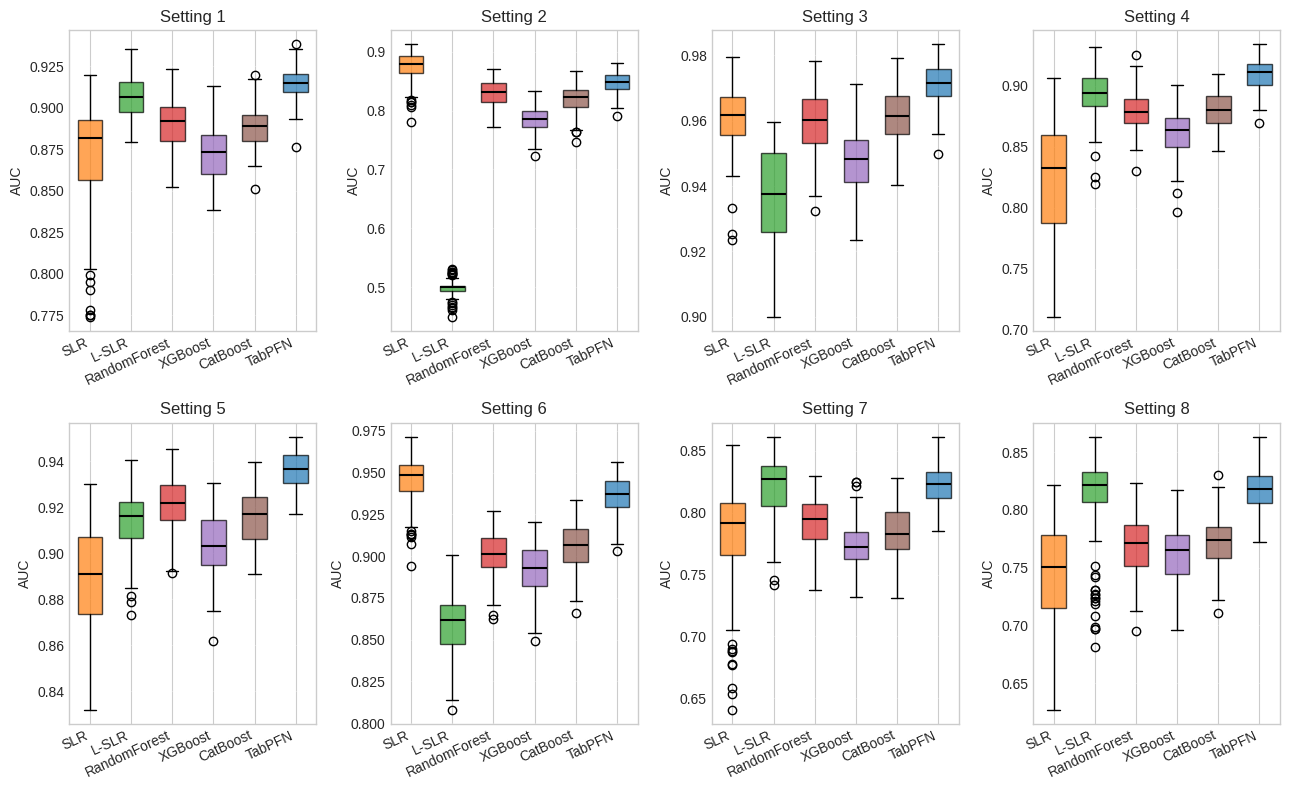

In [ ]:
# MSE boxplots grid
plot_boxplots_grid_lands(errors_dict, setting_names, dir=plots_path, metric='AUC',
                   figsize=(13, 8), save_path='auc_boxplots_grid_land.png')

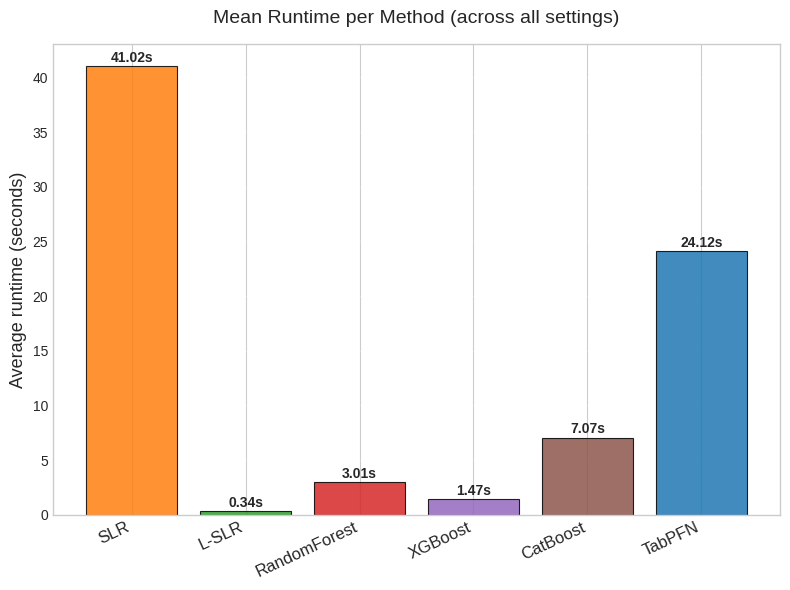

In [ ]:
plot_runtime_barplot_simple(errors_dict, setting_names, dir=plots_path, save_path='runtime_barplot.png')

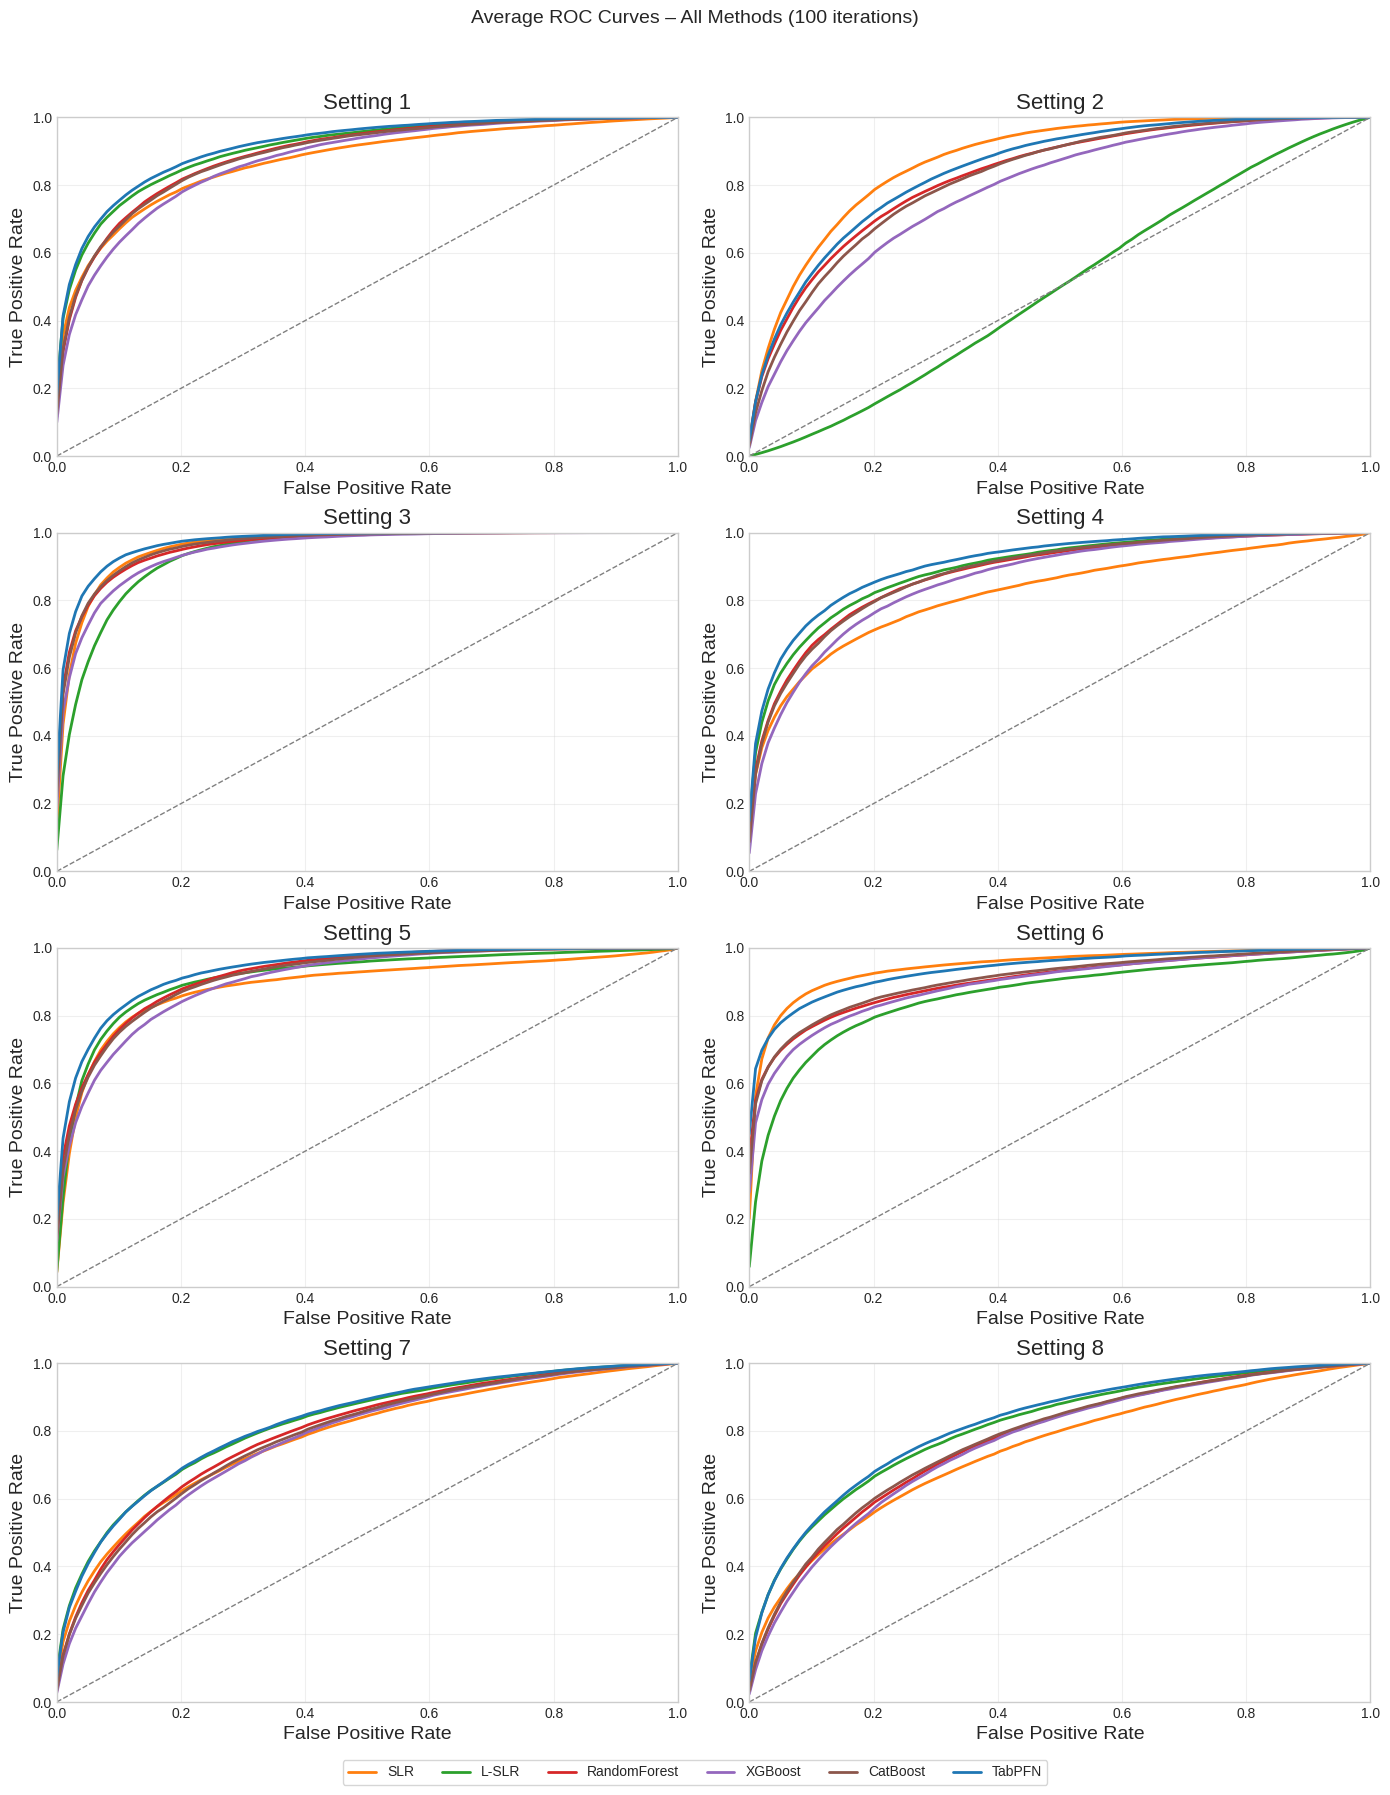

In [ ]:
# AUC boxplots grid
plot_roc_curves_grid(errors_dict, setting_names, dir=plots_path,
                     figsize=(14, 18), save_path='roc_curves_grid.png')

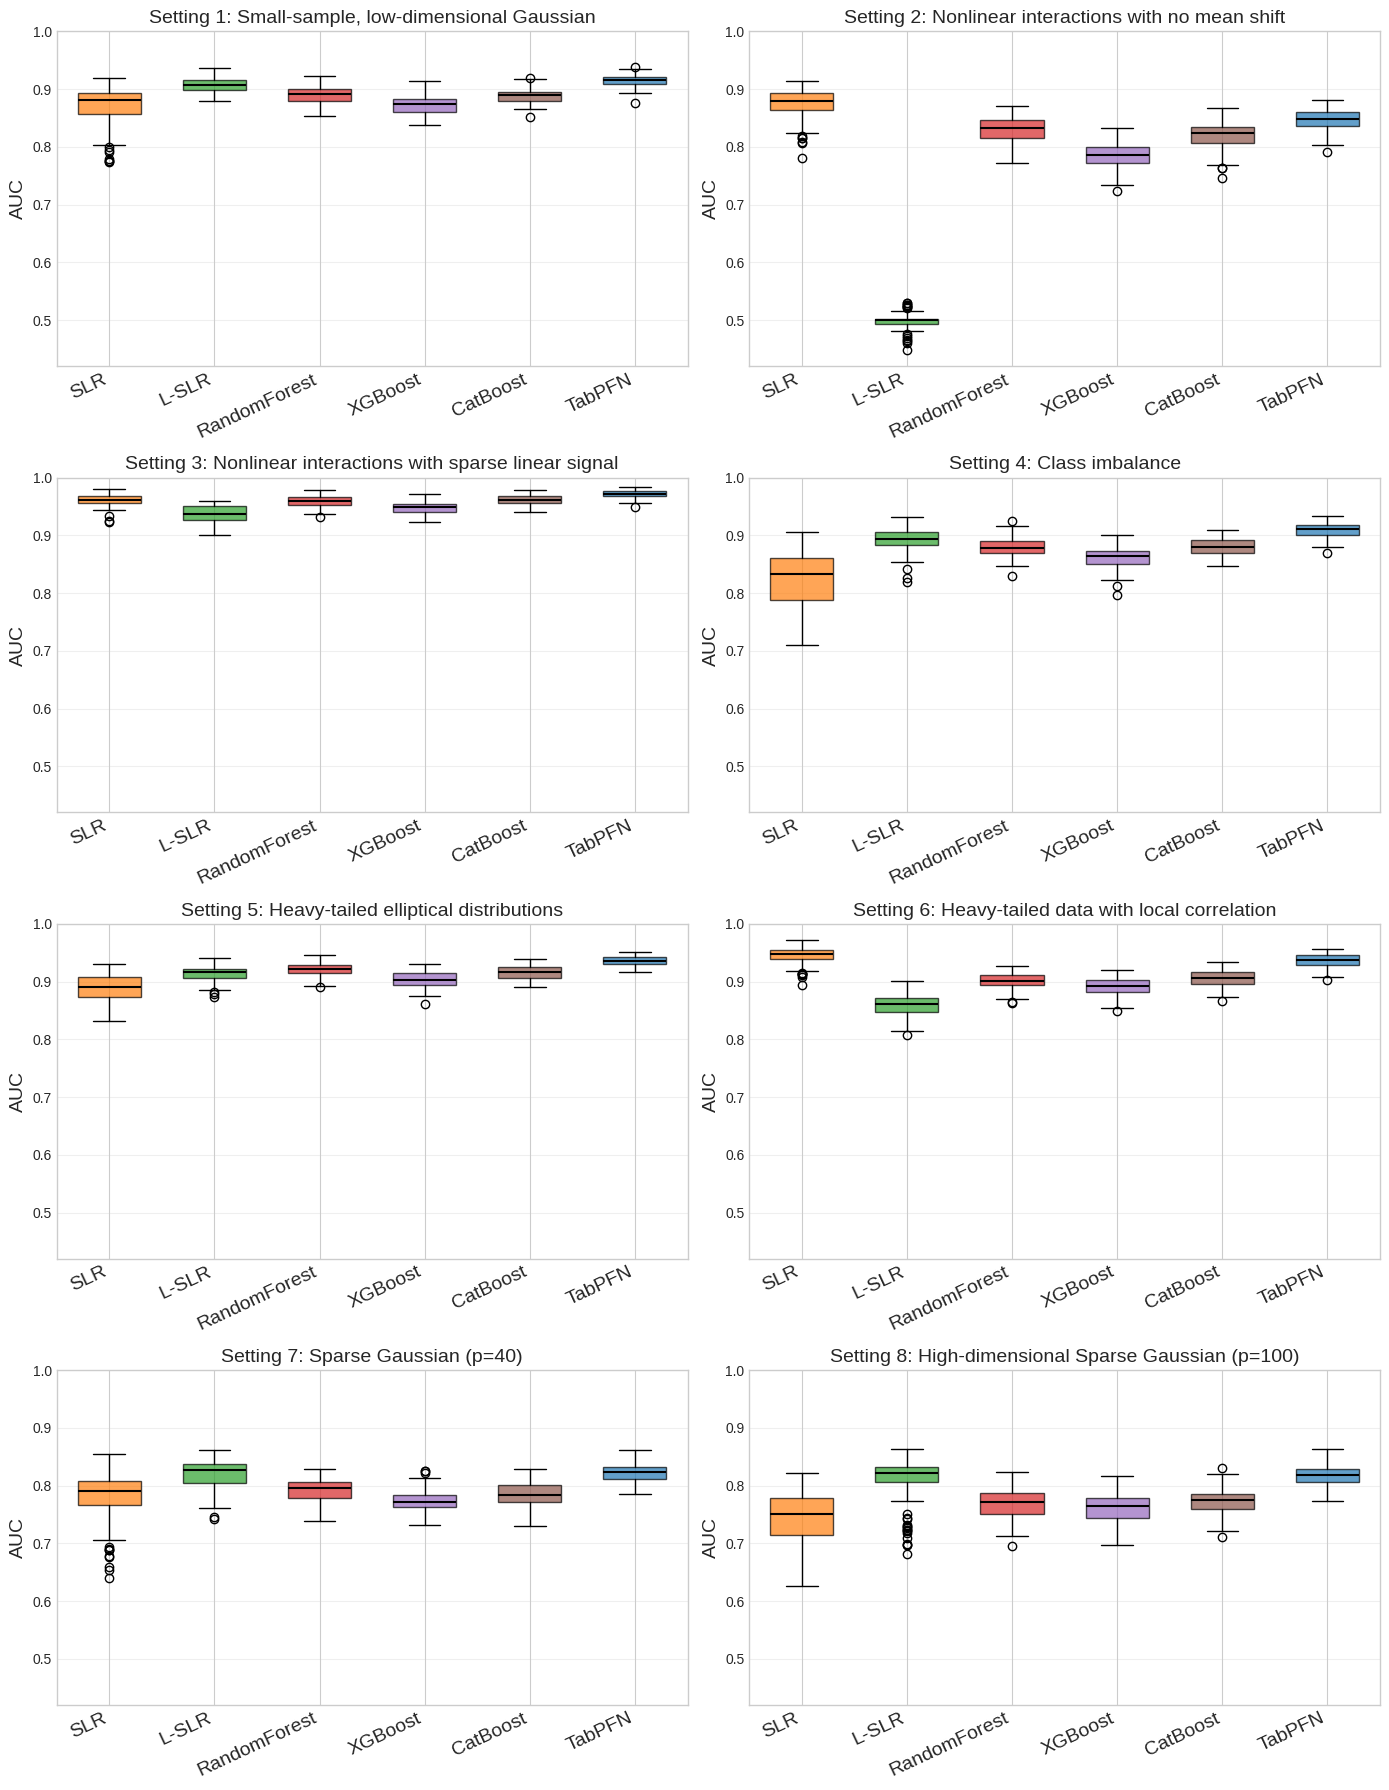

In [ ]:
plot_boxplots_grid(errors_dict, setting_names, dir=plots_path, metric='AUC',
                   figsize=(14, 18), save_path='auc_boxplots_grid.png')

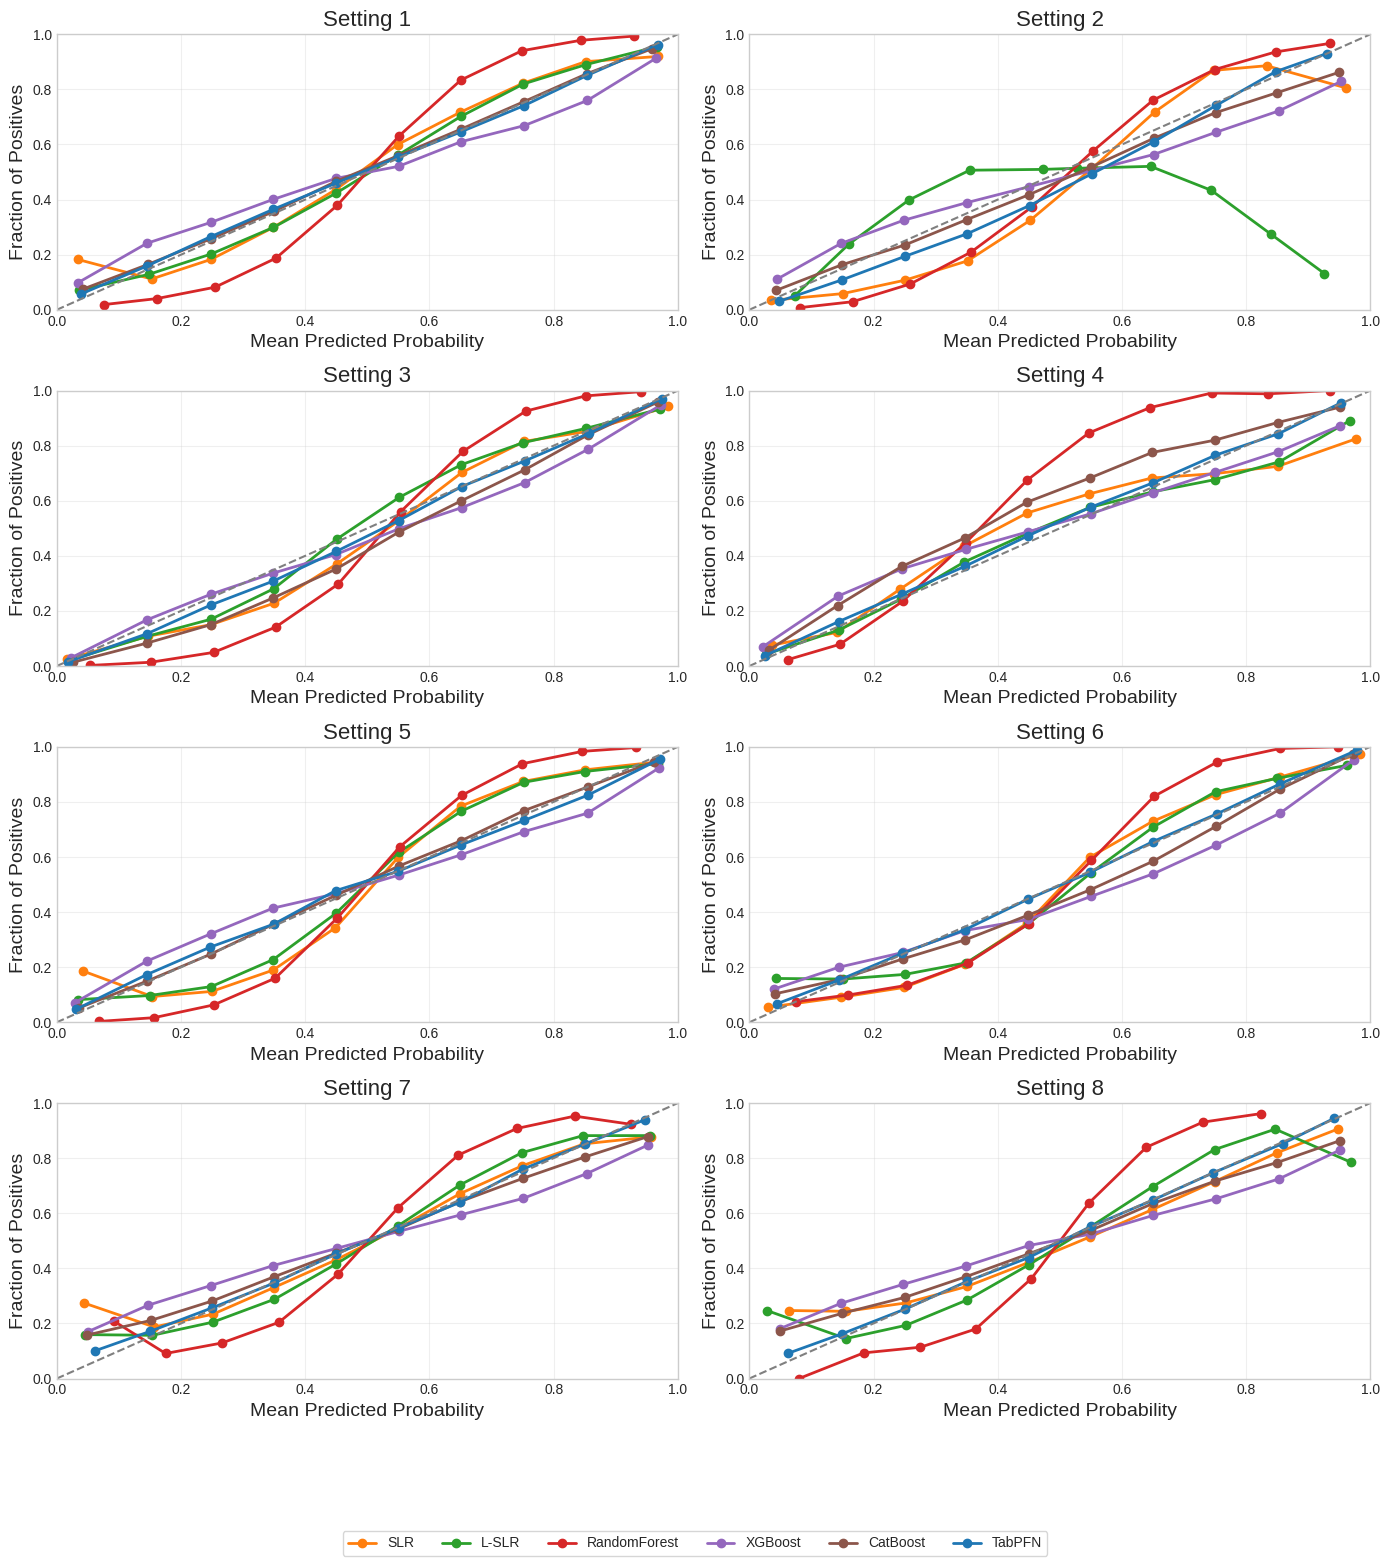

In [ ]:
plot_calibration_grid(errors_dict, setting_names, dir=plots_path,
                      figsize=(14, 16), save_path='calibration_grid.png')

#plot_brier_vs_auc_grid(errors_sens_dict, setting_sens_names, dir=PLOTS_DIR,
 #                      figsize=(14, 17), save_path='brier_vs_auc_grid.png')